# CS4132 Data Analytics Project
## Relation Between Food Production, Trade and Waste
by Jamie Lim Jia Sin (M21405)

## Contents
1. [Motivation & Background](#motivbg)
2. [Summary of Research Questions & Results](#summary)
3. [Datasets](#datasets)
4. [Methodology](#methodology)
    1. [Data Acquisition](#acquisition)
    2. [Data Cleaning](#cleaning)
    3. [Data Exploration & Analysis](#exploration)
        1. Food Production
            - [Q1](#ex1)
            - [Q2](#ex2)
        2. Food Trade
            - [Q3](#ex3)
        3. Food Waste
            - [Q4](#ex4)
5. [Results & Visualisation](#results)
6. [Conclusion & Recommendations](#conclusion)
7. [References](#refs)
8. [Appendix](#appendix)
9. Individual Reflection (not in document)

## Motivation & Background<a id='motivbg'/>
There is increasing emphasis on the environmental issue of food waste locally and worldwide. Through investigating food production, trade and waste trends, and how these relate to factors such as GDP per capita and population size, I hope to learn more about food production and consumption worldwide, as well as gain insight into some possible reasons for food waste that need to be tackled.

For instance, increased urbanisation decreases the amount of space allocated for food production, but new technologies and methods developed could boost food production, hence I would like to analyse trends in global and local food production (e.g. agriculture or aquaculture).

Moreover, there could be many factors affecting how much food a country needs and how much it imports or exports (and whether this is too much or too little), such as the country's demographics or economic status. I hope analysing such patterns will allow me to learn more about food consumption patterns and reasons behind food waste.

## Summary of Research Questions & Results<a id='summary'/>
### Food Production
1. How do amounts of agriculture and aquaculture vary:
    1. Over the years?
        - Worldwide increase in agricultural area from 1960 to 2020, with a sharp increase from 1991 to 1992 due to missing data for Russia and some other countries prior to 1992
        - Worldwide increase in aquaculture production from 1960 to 2020, with an increasing rate of change
    2. Across various countries?
        - Alaska, the United States of America, China and Australia have the greatest mean agricultural area.
        - Countries with the highest percentage of land area used for agriculture are mainly in Europe, Asia or Africa.
        - China's aquaculture production is very much higher than all of the other countries.
    3. In relation to GDP?
        - Food production is positively correlated with GDP per capita worldwide, over time.
    4. In relation to population size?
        - Food production is positively correlated with population size worldwide, over time.
2. How are the amounts of agriculture and aquaculture related?
    - There seems to be increasing focus on aquaculture, but is it really developing so much (compared to other food sources like agriculture)?
    - Worldwide, a larger agricultural area is correlated with more aquaculture production, and overall aquaculture production appears to increase at a slightly faster rate than agricultural area.
    - Further analysis suggests that faster development of aquaculture production and slower increase / decline in agricultural area might be correlated with being more developed.

### Food Trade
3. How do food imports and exports change:
    1. Over the years?
        - Value of both imports and exports have been increasing over the years.
        - Total value of exports is typically higher than that of imports.
    2. In relation to food production, GDP and population size?
        - Food imports are most closely related to aquaculture production, followed by GDP.
        - Food exports are most closely related to GDP, followed by aquaculture production.

### Food Waste
4. How does the amount of food waste generated change:
    1. Over the years?
        - Overall increasing trends in recent years up to 2017.
        - In Singapore, slight decrease from 2017 to 2020.
        - In Singapore, overall increase in recycling rate,  but slight decrease in amount of waste recycled from 2019 to 2020.
    2. Across countries?
        - Australia, Peru, Algeria, Gabon and Oman appear to have the highest recorded median percentages of food waste.
        - There are no particular trends related to the location of countries on the world map.
    3. In relation to food production, food trade, GDP per capita and population size?
        - There is almost no correlation between food waste and any of the above factors.
    4. Across different crops / crop groups?
        - The median percentage is highest for vegetables, followed by fruits and nuts, then edible roots and tubers.
    5. In different stages of the food production/consumption process?
        - Consumers appear to contribute the most food waste, followed by retail, then exports.
        - The maximum percentage loss comes from transport.
        - Storage and transport are some of the most commonly cited causes of food waste.

## Datasets<a id='datasets'/>
1. [Total population](https://data.worldbank.org/indicator/SP.POP.TOTL)
2. [GDP per capita (current USD)](https://data.worldbank.org/indicator/NY.GDP.PCAP.CD)

### Food Production
3. [Agricultural land (sq. km.)](https://data.worldbank.org/indicator/AG.LND.AGRI.K2)
4. [Aquaculture production (metric tons)](https://data.worldbank.org/indicator/ER.FSH.AQUA.MT)
5. [Value of Local Food Production (Singapore)](https://data.gov.sg/dataset/value-of-local-food-production)

### Food Trade

Merchandise trade data is needed for an absolute measurement of food trade to compare across countries.

6. [Food imports (% of merchandise imports)](https://data.worldbank.org/indicator/TM.VAL.FOOD.ZS.UN)
7. [Merchandise imports (current USD)](https://data.worldbank.org/indicator/TM.VAL.MRCH.CD.WT)
8. [Food exports (% of merchandise exports)](https://data.worldbank.org/indicator/TX.VAL.FOOD.ZS.UN)
9. [Merchandise exports (current USD)](https://data.worldbank.org/indicator/TX.VAL.MRCH.CD.WT)

### Food Waste

10. [Food loss and waste (Food and Agriculture Organisation of the United Nations)](http://www.fao.org/platform-food-loss-waste/flw-data/en)
11. [Amount of food waste disposed of, recycled and generated in Singapore from 2011-2020](https://www.nea.gov.sg/our-services/waste-management/3r-programmes-and-resources/food-waste-management)
12. [Central Product Classification 2.1](https://unstats.un.org/unsd/classifications/Econ/Download/In%20Text/CPC_Ver_2_1_english_structure.txt)

## Methodology<a id='methodology'/>

In [1]:
import numpy as np, pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import folium as folium
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from wordcloud import WordCloud
# not used in module notes, might need to pip install ipywidgets if you do not already have it
import ipywidgets as widgets
from ipywidgets import interact, interact_manual

### Data Acquisition<a id='acquisition'/>

In [2]:
# 1: total population
df_pop = pd.read_csv('datasets/population.csv', header=2)
df_pop.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54208.0,55434.0,56234.0,56699.0,57029.0,57357.0,...,102565.0,103165.0,103776.0,104339.0,104865.0,105361.0,105846.0,106310.0,106766.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130836765.0,134159786.0,137614644.0,141202036.0,144920186.0,148769974.0,...,547482863.0,562601578.0,578075373.0,593871847.0,609978946.0,626392880.0,643090131.0,660046272.0,677243299.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,8996967.0,9169406.0,9351442.0,9543200.0,9744772.0,9956318.0,...,31161378.0,32269592.0,33370804.0,34413603.0,35383028.0,36296111.0,37171922.0,38041757.0,38928341.0,NaN


In [3]:
# 2: gdp per capita
df_gdp = pd.read_csv('datasets/gdp per capita usd.csv',header=2)
df_gdp.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,24712.493263,26441.619936,26893.011506,28396.908423,28452.170615,29350.805019,30253.279358,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,147.450369,146.853701,156.017929,182.044085,162.169577,180.017301,...,1667.992618,1648.867514,1654.314865,1503.859334,1401.281053,1536.206783,1530.161917,1481.425292,1326.663658,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,59.773234,59.860900,58.458009,78.706429,82.095307,101.108325,...,641.871438,637.165464,613.856505,578.466353,509.220100,519.888913,493.756581,507.103392,508.808409,NaN


In [4]:
# 3: agricultural land
df_agri = pd.read_csv('datasets/agricultural land sq km.csv',header=2)
df_agri.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Agricultural land (sq. km),AG.LND.AGRI.K2,NaN,20.0,20.0,20.0,20.0,20.0,...,20.00,20.0,20.0,20.0,20.0,20.0,20.00,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Agricultural land (sq. km),AG.LND.AGRI.K2,NaN,5326150.0,5322890.0,5327180.0,5323510.0,5320000.0,...,6459157.24,6477782.4,6497055.3,6505845.2,6515953.0,6521411.4,6532568.32,NaN,NaN,NaN
2,Afghanistan,AFG,Agricultural land (sq. km),AG.LND.AGRI.K2,NaN,377000.0,377600.0,378100.0,378730.0,378750.0,...,379100.00,379100.0,379100.0,379100.0,379100.0,379100.0,379190.00,NaN,NaN,NaN


In [5]:
# 4: agricultural land as percentage of country's land area
df_agri_pc = pd.read_csv('datasets/agricultural area percentage land area.csv',header=2)
df_agri_pc.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Agricultural land (% of land area),AG.LND.AGRI.ZS,NaN,11.111111,11.111111,11.111111,11.111111,11.111111,...,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111,11.111111,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Agricultural land (% of land area),AG.LND.AGRI.ZS,NaN,43.672679,43.645948,43.681124,43.651032,43.622251,...,43.621913,43.747682,43.877935,43.937150,44.005687,44.042629,44.117980,NaN,NaN,NaN
2,Afghanistan,AFG,Agricultural land (% of land area),AG.LND.AGRI.ZS,NaN,57.745918,57.837821,57.914407,58.010906,58.013969,...,58.067580,58.067580,58.067580,58.067580,58.067580,58.067580,58.081365,NaN,NaN,NaN


In [6]:
# 5: aquaculture production
df_aqua = pd.read_csv('datasets/aquaculture production metric tons.csv',header=2)
df_aqua.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Aquaculture production (metric tons),ER.FSH.AQUA.MT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Aquaculture production (metric tons),ER.FSH.AQUA.MT,380.0,410.0,360.0,380.0,430.0,399.0,...,181634.530701,198789.889538,218317.730249,232683.830957,236261.783691,247566.370813,227738.26712,NaN,NaN,NaN
2,Afghanistan,AFG,Aquaculture production (metric tons),ER.FSH.AQUA.MT,NaN,NaN,NaN,NaN,NaN,NaN,...,3480.000000,4110.000000,4760.000000,5450.000000,6150.000000,7000.000000,7950.00000,NaN,NaN,NaN


In [7]:
# 6: value of food production in Singapore
df_prod_value_sg = pd.read_csv('datasets/value-of-local-food-production-in-singapore.csv',header=0)
df_prod_value_sg.head(3)

,year,vegetables,seafood,hen_shell_eggs,local_landings
0,2012,28.6,16.4,48.4,14.8
1,2013,28.9,34.6,59.0,14.3
2,2014,29.6,31.4,63.2,12.6


In [8]:
# 7: food imports
df_food_in = pd.read_csv('datasets/food imports percentage.csv',header=2)
df_food_in.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,NaN,NaN,NaN,NaN,...,31.466398,31.703066,27.918299,30.572758,29.871959,29.570403,27.729279,28.326862,NaN,NaN
1,Africa Eastern and Southern,AFE,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.388647,9.757849,9.418157,9.449429,11.153638,11.622231,10.680818,9.331705,NaN,NaN
2,Afghanistan,AFG,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,7.835267,13.119864,17.335841,17.099851,...,4.276023,7.546840,9.513261,19.227124,23.559998,NaN,34.033057,NaN,NaN,NaN


In [9]:
# 8: merchandise imports
df_merch_in = pd.read_csv('datasets/merchandise imports usd.csv',header=2)
df_merch_in.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Merchandise imports (current US$),TM.VAL.MRCH.CD.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,2.045531e+09,1.376983e+09,1.351229e+09,1.253575e+09,1.208147e+09,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Merchandise imports (current US$),TM.VAL.MRCH.CD.WT,3.792022e+09,3.641874e+09,3.557749e+09,4.025230e+09,4.884584e+09,5.470266e+09,...,2.784894e+11,2.865415e+11,2.876799e+11,2.520715e+11,2.163885e+11,2.336158e+11,2.586190e+11,2.488689e+11,2.093542e+11,NaN
2,Afghanistan,AFG,Merchandise imports (current US$),TM.VAL.MRCH.CD.WT,8.700000e+07,9.900000e+07,1.160000e+08,1.250000e+08,1.240000e+08,1.210000e+08,...,9.069000e+09,8.554000e+09,7.729000e+09,7.723000e+09,6.534000e+09,7.065000e+09,7.407000e+09,6.777000e+09,6.475000e+09,NaN


In [10]:
# 9: food exports
df_food_out = pd.read_csv('datasets/food exports percentage.csv',header=2)
df_food_out.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Food exports (% of merchandise exports),TX.VAL.FOOD.ZS.UN,NaN,NaN,NaN,NaN,NaN,NaN,...,74.968215,74.673023,68.293588,59.034232,50.346782,44.106834,41.646371,43.626885,NaN,NaN
1,Africa Eastern and Southern,AFE,Food exports (% of merchandise exports),TX.VAL.FOOD.ZS.UN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.131017,11.843984,11.060865,12.438250,12.907010,12.874608,12.465233,NaN,NaN,NaN
2,Afghanistan,AFG,Food exports (% of merchandise exports),TX.VAL.FOOD.ZS.UN,NaN,NaN,31.947026,26.51912,32.603264,41.067461,...,17.437223,13.638505,14.495624,48.456109,56.918875,NaN,65.896563,NaN,NaN,NaN


In [11]:
# 10: merchandise exports
df_merch_out = pd.read_csv('datasets/merchandise exports usd.csv',header=2)
df_merch_out.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Merchandise exports (current US$),TX.VAL.MRCH.CD.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,1.388994e+09,2.789940e+08,2.589390e+08,3.341340e+08,3.000000e+08,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Merchandise exports (current US$),TX.VAL.MRCH.CD.WT,4.404234e+09,4.412942e+09,4.663306e+09,5.220639e+09,5.671294e+09,5.865055e+09,...,2.467007e+11,2.438652e+11,2.341077e+11,1.812766e+11,1.699536e+11,1.983847e+11,2.168885e+11,1.993917e+11,1.790258e+11,NaN
2,Afghanistan,AFG,Merchandise exports (current US$),TX.VAL.MRCH.CD.WT,5.000000e+07,5.300000e+07,5.800000e+07,7.000000e+07,6.400000e+07,7.400000e+07,...,4.290000e+08,5.150000e+08,5.700000e+08,5.710000e+08,5.960000e+08,7.230000e+08,8.750000e+08,8.640000e+08,7.830000e+08,NaN


In [12]:
# 11: fao food waste
df_waste = pd.read_csv('datasets/food waste.csv',header=0)
df_waste.head(3)

,geographicaream49,country,region,measureditemcpc,crop,timepointyears,loss_per_clean,percentage_loss_of_quantity,loss_quantity,loss_qualitiative,...,fsc_location1,periodofstorage,treatment,causeofloss,samplesize,units,method_datacollection,tag_datacollection,reference,url
0,100,Bulgaria,NaN,111.0,Wheat,2000,1.80,1.79775798,NaN,NaN,...,SWS_Total,NaN,NaN,NaN,NaN,NaN,17/7/00 X State Farm Inform. System,FAO Sources,FAO Sources,NaN
1,100,Bulgaria,NaN,111.0,Wheat,2000,1.80,1.79775798,NaN,NaN,...,SWS_Total,NaN,NaN,NaN,NaN,NaN,Reuter,FAO Sources,FAO Sources,NaN
2,104,Myanmar,NaN,142.0,"Groundnuts, excluding shelled",2009,5.22,5.219074683,NaN,NaN,...,SWS_Total,NaN,NaN,NaN,NaN,NaN,Myanmar Agricultural Statistics (1997-98 To 20...,FAO Sources,FAO Sources,NaN


In [13]:
# 12: food waste singapore
url = 'https://www.nea.gov.sg/our-services/waste-management/3r-programmes-and-resources/food-waste-management'
waste_url = requests.get(url)
waste_url

<Response [200]>

In [14]:
df_waste_sg = pd.read_html(waste_url.text)
df_waste_sg = df_waste_sg[0]
df_waste_sg.head(3)

,Year,Food Waste Disposed of ('000 tonnes),Food Waste Recycled ('000 tonnes),Total Food Waste Generated ('000 tonnes),Recycling Rate (%)
0,2020,539,126,665,19%
1,2019,607,136,744,18%
2,2018,637,126,763,17%


In [15]:
# 13: Central Product Classification 2.1
df_cpc = pd.read_csv('datasets/CPC 2.1.csv',header=0)
df_cpc.head(3)

,CPC21code,CPC21title
0,0,"Agriculture, forestry and fishery products"
1,1,"Products of agriculture, horticulture and mark..."
2,11,Cereals


In [16]:
world_geo = 'world_countries.json' # geojson file

### Data Cleaning<a id='cleaning'/>

We only need an absolute measure of the amount of money equivalent to food imports / exports. Hence, we multiply the amount of money spent on merchandise imports / earned from merchandise exports by the percentage of food imports / exports respectively.

In [17]:
df_food_in.loc[:,'1960':'2020'] = df_food_in.loc[:,'1960':'2020'] * df_merch_in.loc[:,'1960':'2020'] / 100
df_food_in.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.436549e+08,4.365458e+08,3.772402e+08,3.832525e+08,3.608972e+08,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.893128e+10,2.796028e+10,2.709415e+10,2.381932e+10,2.413519e+10,2.715137e+10,2.762262e+10,2.322371e+10,NaN,NaN
2,Afghanistan,AFG,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,9.088909e+06,1.639983e+07,2.149644e+07,2.069082e+07,...,3.877926e+08,6.455567e+08,7.352799e+08,1.484911e+09,1.539410e+09,NaN,2.520829e+09,NaN,NaN,NaN


In [18]:
df_food_out.loc[:,'1960':'2020'] = df_food_out.loc[:,'1960':'2020'] * df_merch_out.loc[:,'1960':'2020'] / 100
df_food_out.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,Food exports (% of merchandise exports),TX.VAL.FOOD.ZS.UN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.041304e+09,2.083333e+08,1.768387e+08,1.972534e+08,1.510403e+08,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Food exports (% of merchandise exports),TX.VAL.FOOD.ZS.UN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.499329e+10,2.888336e+10,2.589434e+10,2.254764e+10,2.193593e+10,2.554125e+10,2.703566e+10,NaN,NaN,NaN
2,Afghanistan,AFG,Food exports (% of merchandise exports),TX.VAL.FOOD.ZS.UN,NaN,NaN,1.852928e+07,1.856338e+07,2.086609e+07,3.038992e+07,...,7.480569e+07,7.023830e+07,8.262506e+07,2.766844e+08,3.392365e+08,NaN,5.765949e+08,NaN,NaN,NaN


For the WorldBank data, we would like to first merge all the `DataFrame`s into one. We will drop the irrelevant columns, then unpivot all the `DataFrame`s so that we can put each different dataset into one column of the big `DataFrame`. We also rename `Country Name` to `country` for convenience.

In [19]:
def unpivot(df, name):
    df = df.drop(['Country Code','Indicator Name','Indicator Code','Unnamed: 65'],axis='columns')
    df = df.melt(id_vars='Country Name',var_name='year',value_name=name)
    return df.set_index(['Country Name','year'])

df_pop = unpivot(df_pop, 'population')
df_gdp = unpivot(df_gdp, 'gdp')
df_agri = unpivot(df_agri, 'agri')
df_agri_pc = unpivot(df_agri_pc, 'agri_pc')
df_aqua = unpivot(df_aqua, 'aqua')
df_food_in = unpivot(df_food_in, 'food_in')
df_food_out = unpivot(df_food_out, 'food_out')

df_wb = pd.concat([df_pop,df_gdp,df_agri,df_agri_pc,df_aqua,df_food_in,df_food_out],axis=1)
df_wb = df_wb.reset_index()
df_wb = df_wb.rename(columns={'Country Name':'country'})
df_wb

,country,year,population,gdp,agri,agri_pc,aqua,food_in,food_out
0,Aruba,1960,54208.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,1960,130836765.0,147.450369,NaN,NaN,380.0,NaN,NaN
2,Afghanistan,1960,8996967.0,59.773234,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,1960,96396419.0,107.963779,NaN,NaN,2005.0,NaN,NaN
4,Angola,1960,5454938.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
16221,Kosovo,2020,1775378.0,4287.200903,NaN,NaN,NaN,NaN,NaN
16222,"Yemen, Rep.",2020,29825968.0,NaN,NaN,NaN,NaN,NaN,NaN
16223,South Africa,2020,59308690.0,5090.715025,NaN,NaN,NaN,7.062806e+09,1.016838e+10
16224,Zambia,2020,18383956.0,1050.919283,NaN,NaN,NaN,4.623676e+08,5.860078e+08


Next, there are rows containing information from groups of regions/countries. We remove these rows.

We leave the NaN values as missing data for now, because having a few NaN values may not necessarily render the entire row/column of data invalid (e.g. we can analyse only certain data points/columns, or however much of the data is available).

In [20]:
df_wb.country.unique()

array(['Aruba', 'Africa Eastern and Southern', 'Afghanistan',
       'Africa Western and Central', 'Angola', 'Albania', 'Andorra',
       'Arab World', 'United Arab Emirates', 'Argentina', 'Armenia',
       'American Samoa', 'Antigua and Barbuda', 'Australia', 'Austria',
       'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso',
       'Bangladesh', 'Bulgaria', 'Bahrain', 'Bahamas, The',
       'Bosnia and Herzegovina', 'Belarus', 'Belize', 'Bermuda',
       'Bolivia', 'Brazil', 'Barbados', 'Brunei Darussalam', 'Bhutan',
       'Botswana', 'Central African Republic', 'Canada',
       'Central Europe and the Baltics', 'Switzerland', 'Channel Islands',
       'Chile', 'China', "Cote d'Ivoire", 'Cameroon', 'Congo, Dem. Rep.',
       'Congo, Rep.', 'Colombia', 'Comoros', 'Cabo Verde', 'Costa Rica',
       'Caribbean small states', 'Cuba', 'Curacao', 'Cayman Islands',
       'Cyprus', 'Czech Republic', 'Germany', 'Djibouti', 'Dominica',
       'Denmark', 'Dominican Republic', 'Alge

In [21]:
drop_rows = ['Africa Eastern and Southern', 'Africa Western and Central', 'Arab World',
       'Central Europe and the Baltics', 'East Asia & Pacific (excluding high income)',
       'Early-demographic dividend', 'East Asia & Pacific',
       'Europe & Central Asia (excluding high income)', 'Europe & Central Asia',
       'Euro area', 'European Union', 'Fragile and conflict affected situations',
       'High income', 'Heavily indebted poor countries (HIPC)', 'IBRD only',
       'IDA & IBRD total', 'IDA total', 'IDA blend', 'IDA only',
       'Not classified', 'Latin America & Caribbean (excluding high income)',
       'Latin America & Caribbean', 'Least developed countries: UN classification',
       'Low income', 'Lower middle income', 'Low & middle income', 'Late-demographic dividend',
       'Middle East & North Africa', 'Middle income', 
       'Middle East & North Africa (excluding high income)', 'North America', 'OECD members',
       'Other small states', 'Pre-demographic dividend', 'Pacific island small states',
       'Post-demographic dividend', 'South Asia', 'Sub-Saharan Africa (excluding high income)',
       'Sub-Saharan Africa', 'Small states', 'East Asia & Pacific (IDA & IBRD countries)',
       'Europe & Central Asia (IDA & IBRD countries)',
       'Latin America & the Caribbean (IDA & IBRD countries)',
       'Middle East & North Africa (IDA & IBRD countries)',
       'South Asia (IDA & IBRD)', 'Sub-Saharan Africa (IDA & IBRD countries)',
       'Upper middle income']

df_wb = df_wb.replace(to_replace=drop_rows, value='-')
df_wb.drop(df_wb[df_wb.country=='-'].index, axis=0, inplace=True)
df_wb = df_wb.reset_index(drop=True)
df_wb.year = df_wb.year.astype(int)
df_wb

,country,year,population,gdp,agri,agri_pc,aqua,food_in,food_out
0,Aruba,1960,54208.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1960,8996967.0,59.773234,NaN,NaN,NaN,NaN,NaN
2,Angola,1960,5454938.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,1960,1608800.0,NaN,NaN,NaN,0.0,NaN,NaN
4,Andorra,1960,13410.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
13354,Kosovo,2020,1775378.0,4287.200903,NaN,NaN,NaN,NaN,NaN
13355,"Yemen, Rep.",2020,29825968.0,NaN,NaN,NaN,NaN,NaN,NaN
13356,South Africa,2020,59308690.0,5090.715025,NaN,NaN,NaN,7.062806e+09,1.016838e+10
13357,Zambia,2020,18383956.0,1050.919283,NaN,NaN,NaN,4.623676e+08,5.860078e+08


Next, we rename the countries in the same format as the `world_geo` geojson file.

In [22]:
df_wb.country.unique()

array(['Aruba', 'Afghanistan', 'Angola', 'Albania', 'Andorra',
       'United Arab Emirates', 'Argentina', 'Armenia', 'American Samoa',
       'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas, The', 'Bosnia and Herzegovina',
       'Belarus', 'Belize', 'Bermuda', 'Bolivia', 'Brazil', 'Barbados',
       'Brunei Darussalam', 'Bhutan', 'Botswana',
       'Central African Republic', 'Canada', 'Switzerland',
       'Channel Islands', 'Chile', 'China', "Cote d'Ivoire", 'Cameroon',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Colombia', 'Comoros',
       'Cabo Verde', 'Costa Rica', 'Caribbean small states', 'Cuba',
       'Curacao', 'Cayman Islands', 'Cyprus', 'Czech Republic', 'Germany',
       'Djibouti', 'Dominica', 'Denmark', 'Dominican Republic', 'Algeria',
       'Ecuador', 'Egypt, Arab Rep.', 'Eritrea', 'Spain', 'Estonia',
       'Ethiopia', 'Finland', 'Fiji', 'France', 

In [23]:
df_wb = df_wb.replace( {'Bahamas, The':'The Bahamas',
                        'Brunei Darussalam':'Brunei',
                        'Congo, Dem. Rep.':'Democratic Republic of the Congo',
                        'Congo, Rep.':'Republic of the Congo',
                        'Egypt, Arab Rep.':'Egypt',
                        'Gambia, The':'Gambia',
                        'Guinea-Bissau':'Guinea Bissau',
                        'Iran, Islamic Rep.':'Iran',
                        'Kyrgyz Republic':'Kyrgyzstan',
                        'Korea, Rep.':'South Korea',
                        'Lao PDR':'Laos',
                        'North Macedonia':'Macedonia',
                        'Korea, Dem. People\'s Rep.':'North Korea',
                        'Russian Federation':'Russia',
                        'Serbia':'Republic of Serbia',
                        'Slovak Republic':'Slovakia',
                        'Eswatini':'Swaziland',
                        'Syrian Arab Republic':'Syria',
                        'Timor-Leste':'East Timor',
                        'Tanzania':'United Republic of Tanzania',
                        'United States':'United States of America',
                        'Venezuela, RB':'Venezuela',
                        'West Bank and Gaza':'West Bank',
                        'Yemen, Rep.':'Yemen'} )

We also set the years to be the indices of the dataset for value of food production in Singapore, and rename the columns to be more meaningful.

In [24]:
df_prod_value_sg = df_prod_value_sg.set_index('year')
df_prod_value_sg.columns=['farm vegetables','farm seafood','farm eggs','local seafood catch']
df_prod_value_sg.head(3)

,farm vegetables,farm seafood,farm eggs,local seafood catch
year,,,,
2012,28.6,16.4,48.4,14.8
2013,28.9,34.6,59.0,14.3
2014,29.6,31.4,63.2,12.6


We also rename the columns for the Singapore food waste data, and convert the data into tonnes instead of thousand tonnes.

In [25]:
df_waste_sg.columns = ['year','disposed','recycled','total','recycling_rate']
df_waste_sg.disposed = df_waste_sg.disposed * 1000
df_waste_sg.recycled = df_waste_sg.recycled * 1000
df_waste_sg.total = df_waste_sg.total * 1000
df_waste_sg.head(3)

,year,disposed,recycled,total,recycling_rate
0,2020,539000,126000,665000,19%
1,2019,607000,136000,744000,18%
2,2018,637000,126000,763000,17%


#### Cleaning the FAO food waste dataset

In [26]:
df_waste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15156 entries, 0 to 15155
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geographicaream49            15156 non-null  int64  
 1   country                      15156 non-null  object 
 2   region                       822 non-null    object 
 3   measureditemcpc              15156 non-null  float64
 4   crop                         15156 non-null  object 
 5   timepointyears               15156 non-null  int64  
 6   loss_per_clean               15156 non-null  float64
 7   percentage_loss_of_quantity  14188 non-null  object 
 8   loss_quantity                1262 non-null   object 
 9   loss_qualitiative            77 non-null     object 
 10  loss_monetary                69 non-null     object 
 11  activity                     9822 non-null   object 
 12  fsc_location1                15008 non-null  object 
 13  periodofstorage 

In [27]:
len(df_waste.crop.unique())

123

First, we group the crops into categories so that they are easier to analyse, as there are now many different crops. To do this, we make use of the numerical CPC commodity code. (The more digits there are in the code, the more specific the category. We will group the data by the first two digits of the CPC code.)

In [28]:
df_cpc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4596 entries, 0 to 4595
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CPC21code   4596 non-null   int64 
 1   CPC21title  4596 non-null   object
dtypes: int64(1), object(1)
memory usage: 71.9+ KB


In [29]:
# anything from 417 onwards is no longer agricultural, forestry or fishery products -> irrelevant
# may have duplicate CPC codes if not removed
df_cpc = df_cpc.iloc[:417].copy()

In [30]:
df_waste.insert(5, 'crop_group', 'Unknown')

In [31]:
def crop_to_group(row):
    group_code = int(str(row.measureditemcpc)[:2])
    row.crop_group = df_cpc.loc[df_cpc['CPC21code']==group_code,'CPC21title'].values[0]
    return row
df_waste = df_waste.apply(crop_to_group, axis='columns')
df_waste

,geographicaream49,country,region,measureditemcpc,crop,crop_group,timepointyears,loss_per_clean,percentage_loss_of_quantity,loss_quantity,...,fsc_location1,periodofstorage,treatment,causeofloss,samplesize,units,method_datacollection,tag_datacollection,reference,url
0,100,Bulgaria,NaN,111.0,Wheat,Cereals,2000,1.80,1.79775798,NaN,...,SWS_Total,NaN,NaN,NaN,NaN,NaN,17/7/00 X State Farm Inform. System,FAO Sources,FAO Sources,NaN
1,100,Bulgaria,NaN,111.0,Wheat,Cereals,2000,1.80,1.79775798,NaN,...,SWS_Total,NaN,NaN,NaN,NaN,NaN,Reuter,FAO Sources,FAO Sources,NaN
2,104,Myanmar,NaN,142.0,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2009,5.22,5.219074683,NaN,...,SWS_Total,NaN,NaN,NaN,NaN,NaN,Myanmar Agricultural Statistics (1997-98 To 20...,FAO Sources,FAO Sources,NaN
3,104,Myanmar,NaN,142.0,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2008,5.43,5.426717684,NaN,...,SWS_Total,NaN,NaN,NaN,NaN,NaN,Myanmar Agricultural Statistics (1997-98 To 20...,FAO Sources,FAO Sources,NaN
4,104,Myanmar,NaN,142.0,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2007,5.61,5.614486626,NaN,...,SWS_Total,NaN,NaN,NaN,NaN,NaN,Myanmar Agricultural Statistics (1997-98 To 20...,FAO Sources,FAO Sources,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15151,894,Zambia,NaN,112.0,Maize (corn),Cereals,2004,3.60,3.6,NaN,...,Farm,NaN,NaN,NaN,NaN,NaN,Expert Opinon; Literature; Limited Sampling; E...,APHLIS,NaN,https://www.aphlis.net/en/page/2/country-table...
15152,894,Zambia,NaN,112.0,Maize (corn),Cereals,2004,3.80,3.8,NaN,...,Farm,NaN,NaN,NaN,NaN,NaN,Expert Opinon; Literature; Limited Sampling; E...,APHLIS,NaN,https://www.aphlis.net/en/page/2/country-table...
15153,894,Zambia,NaN,112.0,Maize (corn),Cereals,2004,5.40,5.4,NaN,...,Harvest,NaN,NaN,NaN,NaN,NaN,Expert Opinon; Literature; Limited Sampling; E...,APHLIS,NaN,https://www.aphlis.net/en/page/2/country-table...
15154,894,Zambia,NaN,112.0,Maize (corn),Cereals,2004,2.20,2.2,NaN,...,Farm,NaN,NaN,NaN,NaN,NaN,Expert Opinon; Literature; Limited Sampling; E...,APHLIS,NaN,https://www.aphlis.net/en/page/2/country-table...


In [32]:
len(df_waste.crop_group.unique())

12

We are interested in the percentage loss of quantity, as well as the activity during which the food was wasted / the stage or location along the food supply chain that the food was wasted, and the cause of loss.

'loss_per_clean' is actually a cleaned (and rounded) version of 'percentage_loss_of_quantity'. To avoid using pre-cleaned data, we will remove 'loss_per_clean'.

We would like to find out how the data for 'loss_per_clean' was obtained for rows with null 'percentage_loss_of_quantity'.

In [33]:
df_waste.loc[df_waste['percentage_loss_of_quantity'].isna(),['loss_per_clean',
                                                             'percentage_loss_of_quantity',
                                                             'loss_quantity',
                                                             'loss_qualitiative',
                                                             'loss_monetary']]

,loss_per_clean,percentage_loss_of_quantity,loss_quantity,loss_qualitiative,loss_monetary
4530,3.2800,NaN,3.28,NaN,NaN
4531,3.8200,NaN,3.82,NaN,NaN
7567,0.9600,NaN,0.96,NaN,NaN
12541,2.8184,NaN,580589,NaN,NaN
12542,2.7405,NaN,99206,NaN,NaN
...,...,...,...,...,...
13503,2.7110,NaN,1979,NaN,NaN
13504,2.5068,NaN,7019,NaN,NaN
14103,0.0000,NaN,0 tons,0,15-25%
14552,19.8000,NaN,NaN,NaN,NaN


Observing rows 14552 and 14553, all the losses except the cleaned loss were null. For row 14103, although the monetary loss was non-null, the cleaned loss was still determined to be 0. 

There seems to be no clear relation between the cleaned loss and the other columns. As such, we will assume that there was additional (unknown) information used to determine the cleaned loss.

Hence, we will just rely on 'percentage_loss_of_quantity'. We remove the 'loss_per_clean' column, as well as all the rows where 'percentage_loss_of_quantity' is null (since less than 10% of the entries in this column are null).

We also drop all irrelevant columns (e.g. numerical codes, references). ('region' refers to specific regions within the country, so it is also irrelevant.)

In [34]:
df_waste.drop(['loss_per_clean','geographicaream49','region','measureditemcpc','loss_quantity',
             'loss_qualitiative','loss_monetary','periodofstorage','treatment',
             'samplesize','units','method_datacollection','tag_datacollection',
             'reference','url'], axis=1, inplace=True)
df_waste.dropna(subset=['percentage_loss_of_quantity'], axis=0, inplace=True) 
df_waste

,country,crop,crop_group,timepointyears,percentage_loss_of_quantity,activity,fsc_location1,causeofloss
0,Bulgaria,Wheat,Cereals,2000,1.79775798,NaN,SWS_Total,NaN
1,Bulgaria,Wheat,Cereals,2000,1.79775798,NaN,SWS_Total,NaN
2,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2009,5.219074683,NaN,SWS_Total,NaN
3,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2008,5.426717684,NaN,SWS_Total,NaN
4,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2007,5.614486626,NaN,SWS_Total,NaN
...,...,...,...,...,...,...,...,...
15151,Zambia,Maize (corn),Cereals,2004,3.6,NaN,Farm,NaN
15152,Zambia,Maize (corn),Cereals,2004,3.8,Platform drying,Farm,NaN
15153,Zambia,Maize (corn),Cereals,2004,5.4,Harvesting/field drying,Harvest,NaN
15154,Zambia,Maize (corn),Cereals,2004,2.2,Transport to farm,Farm,NaN


Next, for convenience and neatness, we will rename the columns and indices.

In [35]:
df_waste.rename(columns={'timepointyears':'year',
                       'percentage_loss_of_quantity':'loss',
                       'fsc_location1':'stage',
                       'causeofloss':'cause'}, inplace=True)
df_waste

,country,crop,crop_group,year,loss,activity,stage,cause
0,Bulgaria,Wheat,Cereals,2000,1.79775798,NaN,SWS_Total,NaN
1,Bulgaria,Wheat,Cereals,2000,1.79775798,NaN,SWS_Total,NaN
2,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2009,5.219074683,NaN,SWS_Total,NaN
3,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2008,5.426717684,NaN,SWS_Total,NaN
4,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2007,5.614486626,NaN,SWS_Total,NaN
...,...,...,...,...,...,...,...,...
15151,Zambia,Maize (corn),Cereals,2004,3.6,NaN,Farm,NaN
15152,Zambia,Maize (corn),Cereals,2004,3.8,Platform drying,Farm,NaN
15153,Zambia,Maize (corn),Cereals,2004,5.4,Harvesting/field drying,Harvest,NaN
15154,Zambia,Maize (corn),Cereals,2004,2.2,Transport to farm,Farm,NaN


We now rename the countries to be consistent with the other datasets.

In [36]:
df_waste.country.unique()

array(['Bulgaria', 'Myanmar', 'Burundi', 'Belarus', 'Cambodia', 'Algeria',
       'Cameroon', 'Canada', 'Sri Lanka', 'Chad', 'Chile', 'China',
       'Colombia', 'Democratic Republic of the Congo', 'Costa Rica',
       'Cuba', 'Cyprus', 'Czechia', 'Benin', 'Denmark', 'Ecuador',
       'El Salvador', 'Ethiopia', 'Eritrea', 'Estonia', 'Angola', 'Fiji',
       'Finland', 'France', 'Gabon', 'Georgia', 'Gambia', 'Germany',
       'Ghana', 'Azerbaijan', 'Argentina', 'Guatemala', 'Guinea',
       'Guyana', 'Honduras', 'Hungary', 'India', 'Australia', 'Indonesia',
       'Iran (Islamic Republic of)', 'Ireland', 'Israel', 'Italy',
       "Côte d'Ivoire", 'Japan', 'Kazakhstan', 'Afghanistan', 'Austria',
       'Jordan', 'Kenya', "Democratic People's Republic of Korea",
       'Republic of Korea', 'Kyrgyzstan',
       "Lao People's Democratic Republic", 'Lesotho', 'Liberia',
       'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia',
       'Mali', 'Mauritania', 'Bahrain', 'Mauritius', 

In [37]:
df_waste.replace({'Czechia':'Czech Republic',
                  'Iran (Islamic Republic of)':'Iran',
                  'Côte d\'Ivoire':'Cote d\'Ivoire',
                  'Democratic People\'s Republic of Korea':'North Korea',
                  'Republic of Korea':'South Korea',
                  'Lao People\'s Democratic Republic':'Laos',
                  'Guinea-Bissau':'Guinea Bissau',
                  'Timor-Leste':'East Timor',
                  'Russian Federation':'Russia',
                  'Bolivia (Plurinational State of)':'Bolivia',
                  'Serbia':'Republic of Serbia',
                  'Viet Nam':'Vietnam',
                  'Venezuela (Bolivarian Republic of)':'Venezuela'})

,country,crop,crop_group,year,loss,activity,stage,cause
0,Bulgaria,Wheat,Cereals,2000,1.79775798,NaN,SWS_Total,NaN
1,Bulgaria,Wheat,Cereals,2000,1.79775798,NaN,SWS_Total,NaN
2,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2009,5.219074683,NaN,SWS_Total,NaN
3,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2008,5.426717684,NaN,SWS_Total,NaN
4,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2007,5.614486626,NaN,SWS_Total,NaN
...,...,...,...,...,...,...,...,...
15151,Zambia,Maize (corn),Cereals,2004,3.6,NaN,Farm,NaN
15152,Zambia,Maize (corn),Cereals,2004,3.8,Platform drying,Farm,NaN
15153,Zambia,Maize (corn),Cereals,2004,5.4,Harvesting/field drying,Harvest,NaN
15154,Zambia,Maize (corn),Cereals,2004,2.2,Transport to farm,Farm,NaN


Next, we clean the values in the 'loss' column. We use `df_waste.loss.astype(float)` to see what the remaining formatting error(s) is/are.

In [38]:
df_waste.loc[df_waste.loss.str.endswith('%'),'loss'] = df_waste.loc[df_waste.loss.str.endswith('%'),'loss'].str[:-1]

In [39]:
def average_ranges(row):
    if row.loss.find('+/-') != -1: # middle +- uncertainty
        row.loss = row.loss.split('+')[0]
    elif row.loss.find('-') != -1: # range
        loss_range = row.loss.split('-')
        row.loss = str((float(loss_range[0]) + float(loss_range[1]))/2)
    return row

df_waste = df_waste.apply(average_ranges,axis='columns')

In [40]:
def replace_characters(row):
    if row.loss.find('â€“') != -1:
        loss_split = row.loss.split('â€“')
        row.loss = loss_split[0] + '.' + loss_split[1]
    return row

df_waste = df_waste.apply(replace_characters,axis='columns')

In [41]:
df_waste.loc[:,'loss'] = df_waste.loss.astype(float)
df_waste.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14188 entries, 0 to 15155
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     14188 non-null  object 
 1   crop        14188 non-null  object 
 2   crop_group  14188 non-null  object 
 3   year        14188 non-null  int64  
 4   loss        14188 non-null  float64
 5   activity    9820 non-null   object 
 6   stage       14042 non-null  object 
 7   cause       1013 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 997.6+ KB


Then, we remove identical rows.

In [42]:
df_waste = df_waste.drop_duplicates()
df_waste

,country,crop,crop_group,year,loss,activity,stage,cause
0,Bulgaria,Wheat,Cereals,2000,1.797758,NaN,SWS_Total,NaN
2,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2009,5.219075,NaN,SWS_Total,NaN
3,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2008,5.426718,NaN,SWS_Total,NaN
4,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2007,5.614487,NaN,SWS_Total,NaN
5,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2006,5.397461,NaN,SWS_Total,NaN
...,...,...,...,...,...,...,...,...
15150,Zambia,Maize (corn),Cereals,2004,2.700000,Market storage,Wholesale,NaN
15151,Zambia,Maize (corn),Cereals,2004,3.600000,NaN,Farm,NaN
15152,Zambia,Maize (corn),Cereals,2004,3.800000,Platform drying,Farm,NaN
15153,Zambia,Maize (corn),Cereals,2004,5.400000,Harvesting/field drying,Harvest,NaN


Next, we clean the values in the 'stage' column.

In [43]:
df_waste.stage.value_counts()

Farm                 4335
SWS_Total            2123
Storage              1633
Harvest              1348
Transport            1286
Wholesale            1269
Retail                327
WholeSupplyChain      198
Processing            148
Distribution           80
ParameterEstimate      47
Export                 44
Trader                 39
Traders                25
Consumer               23
Restaurants            10
Packaging               9
Grading                 6
Pre-Harvest             5
Stacking                3
-                       3
Havest                  1
Market                  1
Name: stage, dtype: int64

In [44]:
df_waste = df_waste.replace({'-':np.nan,
                             'Havest':'Harvest',
                             'Pre-Harvest':'Harvest',
                             'Market':'Retail',
                             'Packaging':'Processing',
                             'Grading':'Processing',
                             'Trader':'Traders',
                             'WholeSupplyChain':'Whole Supply Chain',
                             'SWS_Total':'Whole Supply Chain', # assume this means the whole thing
                             'ParameterEstimate':'Unknown', # not useful, so treat it as unknown
                             'Stacking':'Unknown', # unsure what this means, treat it as unknown
                            })
df_waste = df_waste.replace({'Harvest':'(Pre-)Harvest'})
df_waste.stage.value_counts()

Farm                  4335
Whole Supply Chain    2321
Storage               1633
(Pre-)Harvest         1354
Transport             1286
Wholesale             1269
Retail                 328
Processing             163
Distribution            80
Traders                 64
Unknown                 50
Export                  44
Consumer                23
Restaurants             10
Name: stage, dtype: int64

Finally, we replace all the `NaN` activities/stages/causes with "Unknown".

In [45]:
df_waste.fillna('Unknown', inplace=True)
df_waste

,country,crop,crop_group,year,loss,activity,stage,cause
0,Bulgaria,Wheat,Cereals,2000,1.797758,Unknown,Whole Supply Chain,Unknown
2,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2009,5.219075,Unknown,Whole Supply Chain,Unknown
3,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2008,5.426718,Unknown,Whole Supply Chain,Unknown
4,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2007,5.614487,Unknown,Whole Supply Chain,Unknown
5,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2006,5.397461,Unknown,Whole Supply Chain,Unknown
...,...,...,...,...,...,...,...,...
15150,Zambia,Maize (corn),Cereals,2004,2.700000,Market storage,Wholesale,Unknown
15151,Zambia,Maize (corn),Cereals,2004,3.600000,Unknown,Farm,Unknown
15152,Zambia,Maize (corn),Cereals,2004,3.800000,Platform drying,Farm,Unknown
15153,Zambia,Maize (corn),Cereals,2004,5.400000,Harvesting/field drying,(Pre-)Harvest,Unknown


In [46]:
# reset the indices
df_waste = df_waste.reset_index(drop=True)
df_waste.head(3)

,country,crop,crop_group,year,loss,activity,stage,cause
0,Bulgaria,Wheat,Cereals,2000,1.797758,Unknown,Whole Supply Chain,Unknown
1,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2009,5.219075,Unknown,Whole Supply Chain,Unknown
2,Myanmar,"Groundnuts, excluding shelled",Oilseeds and oleaginous fruits,2008,5.426718,Unknown,Whole Supply Chain,Unknown


Note that for each observation in the dataset, the percentage of food lost is for that crop, in that country, in that year, from a certain stage in the food production process. We cannot simply add the values together.

### Data Exploration & Analysis<a id='exploration'/>
We will mainly focus our comparison across countries to the following countries: Singapore, US, UK, China and India. We choose Singapore because it is most relevant to us as residents, and the remaining four as they are considered some of the most influential countries, and all of these countries can provide varied demographics/possible factors affecting the food production/trade/waste, such as population.

#### Food Production
##### Q1<a id='ex1'/>
How do amounts of agriculture and aquaculture vary:

###### A. Over the years?
We draw point plots of the area used for agriculture (which is likely to be related to amount of agriculture), percentage of country's (or world's) area used for agriculture and aquaculture production, against time.

In [47]:
label_dict = {'population':'population size',
              'gdp':'GDP per capita',
              'agri':'agricultural area (sq. km)',
              'agri_pc':'percentage of land used for agriculture',
              'aqua':'aquaculture production (metric tonnes)',
              'food_in':'value of food imports',
              'food_out':'value of food exports',
              'net_trade':'net food trade'}
countries = ['World','Singapore','United States of America','United Kingdom','China','India']

In [48]:
def year_pointplot(y,data,figsize,ylabel,title,hue=None):
    plt.figure(figsize=figsize)
    sns.pointplot(x='year',y=y,hue=hue,data=data)
    plt.xticks(ticks=np.arange(0,len(data['year'].unique()),5))
    plt.xlabel('years')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

In [49]:
def eda_q1a_pointplot(y, country, start_year, end_year):
    if start_year > end_year:
        return 'Error: end year cannot be before start year'
    ylabel = y.title().lower()
    mask = (df_wb.country==country)&(df_wb.year>=start_year)&(df_wb.year<=end_year)
    year_pointplot(df_wb.loc[mask,ylabel], df_wb.loc[mask], (15,8), label_dict[ylabel],
                label_dict[ylabel]+' from '+str(start_year)+' to '+str(end_year)+' in '+country)

interact(eda_q1a_pointplot,
         y=widgets.Dropdown(options=list(df_wb.select_dtypes('float64').columns[2:5]),description='y-axis'),
         country=widgets.Dropdown(options=countries,value='World'),
         start_year=widgets.IntSlider(min=1960,max=2020,step=1,value=1960,description='start year'),
         end_year=widgets.IntSlider(min=1960,max=2020,step=1,value=2020,description='end year'))

interactive(children=(Dropdown(description='y-axis', options=('agri', 'agri_pc', 'aqua'), value='agri'), Dropd…

<function __main__.eda_q1a_pointplot(y, country, start_year, end_year)>

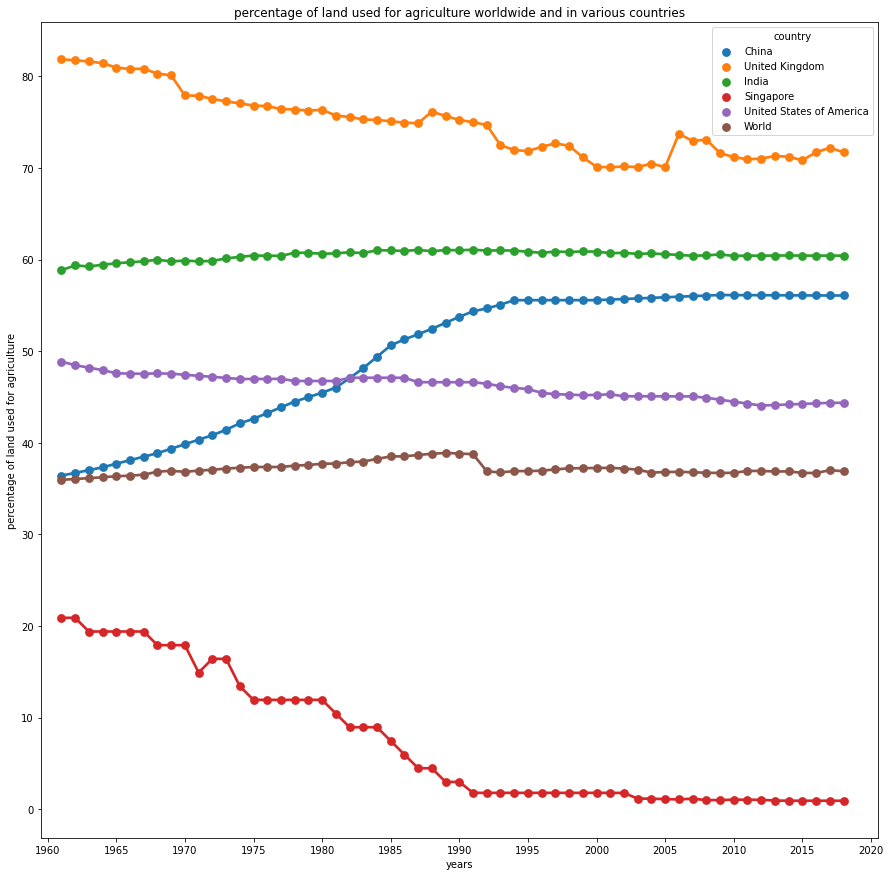

In [50]:
def eda_q1a_agri_pc_pointplots():
    mask = (df_wb.country==countries[0])
    for i in range(1,len(countries)):
        mask = mask|(df_wb.country==countries[i])
    year_pointplot(df_wb.loc[mask,'agri_pc'], df_wb.loc[mask], (15,15), label_dict['agri_pc'],
                  label_dict['agri_pc'] + ' worldwide and in various countries', 'country')

eda_q1a_agri_pc_pointplots()

###### Agricultural area over the years
**Worldwide:** for the absolute agricultural area, there is an overall increase, but in particular there is a sharp increase from 1991 to 1992. There is also slight plateauing (with a bit of fluctuation) after 1992, with another notable increase from 2010 to 2011 (though not as significant as the one at 1991). Meanwhile, for the percentage of land used for agriculture, there is a steady increase until around 1989, after which we see a sharp _decrease_ from 1991 to 1992; subsequently, there is some fluctuation but it is generally kept within the range 36.5% to 37.5%, and there is also a notable increase from 2010 to 2011.

This brings us to suspect that the sharp change from 1991 to 1992 is due to a change in definitions or the method of detection of land/agricultural area, rather than an actual sudden increase in agricultural area. We will investigate this further below.

**Singapore:** there is a generally linear decrease until about 1991 where the agricultural area remained relatively constant after that (very slightly decreasing). The percentage area also shows a similar trend (decrease from slightly above 20% to close to 0%). Singapore is the only country out of the 5 chosen whose percentage area for agriculture is below the worldwide value. This is rather expected as land-scarce Singapore underwent rapid development/urbanisation over the first several years from independence onwards, leading to a decrease in agricultural land as more space was needed for urban development.

Not much information could be found about regulations regarding agriculture in the past. [Singapore Food Agency (SFA)](https://www.sfa.gov.sg/food-farming/food-farms/farming-in-singapore) states that our land-based food farms currently occupy less than 1% of our total land area, and the farms are mostly located in Lim Chu Kang and Sungei Tengah. We venture a guess that there were plans to only have farms in a few main places, and hence any other farms were rapidly being replaced prior to 1991.

**US:** there is a general decrease until 2012, with the exception of a slight increase to a plateau from 1982 to 1986, and then another slight increase after 2012. The percentage area also shows a similar trend, and in comparison to the other countries there is actually not a very large decrease in percentage area for agriculture. This could be because the US has large land area, so even with increasing urbanisation, there is enough land for some agricultural activities to continue (more than in Singapore).

**UK:** there is a general decreasing trend until 2000, followed by a sharp increase from 2005 to 2006, and then a slight decrease to some fluctuation from 2009 onwards. The percentage area shows a similar trend. The UK was the country with the second largest percentage decrease in agricultural area among the countries chosen, with the largest being Singapore. This could be because the UK is more land-scarce than the US, China and India, but still has more land than Singapore.

**China:** there is a generally increasing trend, with a steeper increase from 1960 to 1994 and then a much slower increase (almost plateau) from 1994 onwards. The percentage area shows a similar trend. China's percentage area for agriculture was almost the same as the worldwide value in 1961 (around 37-38%), and increased to around 55% in 2018. This makes sense as China is still considered a developing country.

**India:** there is increasing trend that slows down until around 1990 where the agricultural area starts to decrease, until a plateau from 2010 onwards. These changes do not seem to reflect much variance in the percentage area of land for agriculture, which suggests India has not had much need to significantly increase or decrease the amount of resources used for agriculture.

Next, we want to find out (if possible) what factors or which country/countries caused the sudden sharp change in the worldwide data from 1991 to 1992.

In [51]:
agri = df_wb[['country','year','agri']].copy()
agri = agri[(agri.year==1991)|(agri.year==1992)].pivot(columns='year',index='country')
agri.columns = agri.columns.droplevel()
agri = agri.loc[:,1992] - agri.loc[:,1991]
print(agri.sort_values(ascending=False).dropna().head(16))
agri.sort_values(ascending=False).dropna().tail(15)

country
World                          6011572.086
Australia                        32220.000
China                            29270.000
Niger                             8950.000
Iran                              7900.000
Nigeria                           5180.000
South Africa                      4680.000
United Republic of Tanzania       3720.000
Egypt                             3532.800
Vietnam                           2740.000
Morocco                           2610.000
Paraguay                          2554.210
Cote d'Ivoire                     2500.000
Algeria                           2430.000
Zambia                            2390.000
Mozambique                        2190.000
dtype: float64


country
France                      -1006.0
Thailand                    -1420.0
Yemen                       -1500.0
New Zealand                 -1590.0
Turkey                      -1630.0
Indonesia                   -1730.0
Germany                     -1850.0
Chile                       -2330.0
Venezuela                   -2500.0
India                       -2810.0
Hungary                     -3240.0
Bangladesh                  -7710.0
Brazil                     -14198.0
United States of America   -15190.0
Mongolia                   -25400.0
dtype: float64

Australia had quite a large jump from 1991 to 1992. Also, the top 15 increasing countries seemed to change notably more than the top 15 decreasing countries. (Almost all of the values among the top increasing countries have larger magnitude than the corresponding decreasing country.)

We try to plot the graph for Australia to see if we can gain any insights.

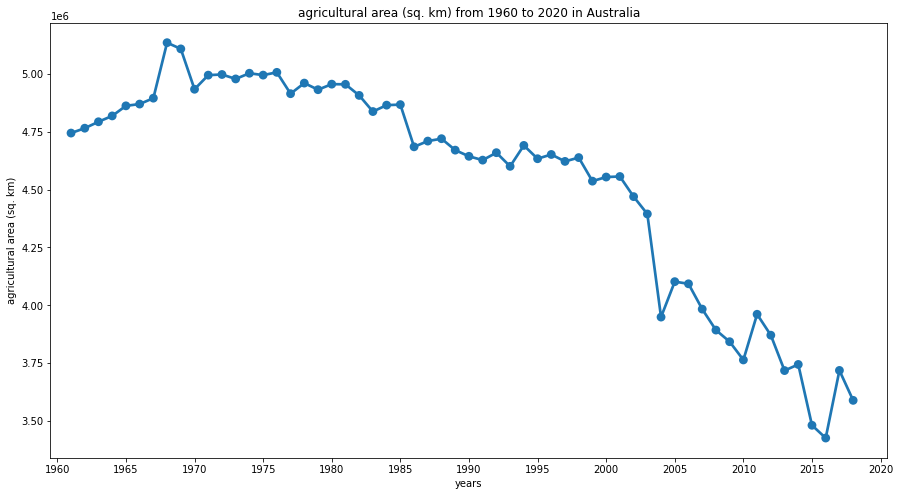

In [52]:
ylabel = 'agri'
mask = (df_wb.country=='Australia')
year_pointplot(df_wb.loc[mask,ylabel], df_wb.loc[mask], (15,8), label_dict[ylabel],
            label_dict[ylabel]+' from 1960 to 2020 in Australia')

Australia was in fact on an overall _decreasing_ trend from 1968 all the way until the 2000s. Even though it countributed the largest absolute increase in agricultural area, we doubt it was the sole cause of the significant spike, because the worldwide trend was increasing overall. We try to compare the 1991-1992 change to the 1990-1991 change and the 1992-1993 change instead.

In [53]:
agri = df_wb[['country','year','agri']].copy()
agri = agri[(agri.year>=1990)|(agri.year<=1993)].pivot(columns='year',index='country')
agri.columns = agri.columns.droplevel()
before = (agri.loc[:,1992] - agri.loc[:,1991]) - (agri.loc[:,1991] - agri.loc[:,1990])
after = (agri.loc[:,1992] - agri.loc[:,1991]) - (agri.loc[:,1993] - agri.loc[:,1992])
print(before.sort_values(ascending=False).dropna().head(15))
after.sort_values(ascending=False).dropna().head(15)

country
World            6083705.712
Angola            119967.800
Australia          48770.000
Indonesia          33860.000
Liberia            13862.400
Ireland            11780.000
Germany             7110.000
Italy               7100.000
Egypt               3582.800
Colombia            2980.000
Algeria             2970.000
Morocco             2490.000
Vietnam             2490.000
Senegal             2310.000
Cote d'Ivoire       2300.000
dtype: float64


country
World                       6131140.906
Ethiopia                     255120.000
Australia                     91290.000
Mongolia                      19260.000
United States of America       9620.000
Niger                          8950.000
United Kingdom                 4630.000
Kenya                          4270.000
Iran                           4250.000
Egypt                          3343.800
Algeria                        2460.000
Vietnam                        2120.000
Colombia                       1790.000
Morocco                        1660.000
Spain                          1540.000
dtype: float64

Here we have a few more possible "culprits" - in Angola, the change from 1991 to 1992 (increase) was much more than that from 1990 to 1991 (decrease), and in Ethiopia, the change from 1991 to 1992 (increase) was much more than that from 1992 to 1993 (decrease).

In [54]:
agri_pc = df_wb[['country','year','agri_pc']].copy()
agri_pc = agri_pc[(agri_pc.year==1991)|(agri_pc.year==1992)].pivot(columns='year',index='country')
agri_pc.columns = agri_pc.columns.droplevel()
agri_pc = agri_pc.loc[:,1992] - agri_pc.loc[:,1991]
print(agri_pc.sort_values(ascending=False).dropna().head(15))
agri_pc.sort_values(ascending=False).dropna().tail(15)

country
Djibouti          1.509922
Belgium           1.462523
Jordan            1.250000
Bahrain           1.081853
American Samoa    1.000000
Tunisia           0.933316
Vietnam           0.841808
Cote d'Ivoire     0.786164
Niger             0.706560
Isle of Man       0.701754
Paraguay          0.642892
Fiji              0.602080
Morocco           0.584808
Nigeria           0.568750
Syria             0.549570
dtype: float64


country
Mauritius                        -0.492611
Germany                          -0.529889
Malawi                           -0.530335
New Zealand                      -0.603851
Samoa                            -0.706714
Haiti                            -0.761974
Costa Rica                       -0.854250
St. Vincent and the Grenadines   -0.923077
Puerto Rico                      -1.127396
Rwanda                           -1.621403
Mongolia                         -1.634955
World                            -1.868040
Gambia                           -3.359684
Hungary                          -3.605208
Bangladesh                       -5.923024
dtype: float64

As for the percentage area used for agriculture, we notice that there were quite a few countries with significant drops from 1991 to 1992, especially Gambia, Hungary and Bangladesh (greater drop than World).

Along with our earlier observations, we assume that it is likely that many countries' data contributed to the sharp change from 1991 to 1992. Yet, it also does not appear that all the countries contributed equally. We do not rule out the possibility that there was a change in definitions or detections, but we are unable to verify this as the website does not mention it.

For future analysis involving agricultural area, we will consider each range from 1960 to 1991 and 1992 to 2020 separately, as well as the entire range from 1960 to 2020.

**Note: this has in fact allowed us to discover the real reason behind the significant changes** - data for Russia and some of its neighbouring countries were not available prior to 1992. See [Q1B](#1b).

Due to the large land area covered by these countries, of which not a large percentage was used for agriculture, the addition of these data points increased the absolute land area significantly but caused the percentage land area to decrease.

We will still consider the year ranges separately as this will likely continue to affect some of the later results.

###### Aquaculture production over the years
**Worldwide:** aquaculture production has been increasing at an increasing rate over the years. As compared to the relatively linear trend (other than the jump from 1991 to 1992) in agriculture, this suggests aquaculture might be expanding at a faster rate than agriculture. This will be explored further in [Q2](#ex2).

**Singapore:** there has been a plateau (very slight increase) until about 1980, followed by an overall increasing trend, until a sudden drop from over 8000 metric tonnes in 2006 to less than 5000 metric tonnes in 2007 and less than 4000 metric tonnes in 2008, after which the aquaculture production began to increase again.

According to an old article on the [FAO website](http://www.fao.org/3/X5629E/x5629e0k.htm), the transition from a plateau to an increasing trend could likely be because of the various policies and other efforts to increase aquaculture production in Singapore due to the high demand and low local supply of aquaculture products in the 1970s/1980s. Not much information appears to be available on the situation from 2006-2008.

**US:** there is a generally increasing trend until 2004, followed by a drop until 2011 and then a gradual increase after 2011.

**UK:** there has been a plateau (very slight increase) until about 1980, followed by an overall increasing trend, until a noticeable drop from 2004 to 2005, after which the aquaculture production began to increase again, but at a slower rate than before. Perhaps the efforts to increase aquaculture production in Singapore in the 1970s/1980s were influenced by actions taken by the UK or vice versa.

Additionally, the decrease in around 2004 appears to have occurred in the US and the UK, and this was quite close to the decrease in 2006 in Singapore. Not much information appears to be available on the situation. We venture a guess that these were random occurrences, possibly due to the data collection methods, as this was not a worldwide trend.

**China and India:** these two countries showed similar trends of a very slow rate of increase initially until around the 1980s/1990s where the rate of increase began to increase. This could possibly be due to their similarities in location, population size and other factors affecting the demand for as well as availability of aquaculture products.

Next, we draw side-by-side boxplots for the percentage area used for agriculture worldwide over the years.

In [55]:
def eda_year_boxplots(df):
    # remove world data to avoid skewing the axis scale because of one outlier
    # pivot the dataframe so that each year is a new column
    df_plot = df[df.country!='World'].set_index('country').pivot(columns='year')
    ylabel = df_plot.columns[0][0]
    df_plot.columns = df_plot.columns.droplevel() # remove agri_pc from the column names
    df_plot.plot(kind='box',figsize=(15,8))
    plt.xticks(ticks=np.arange(1,62,5))
    plt.xlabel('years')
    plt.ylabel(label_dict[ylabel])
    plt.title(label_dict[ylabel] + ' across countries from 1960 to 2020')

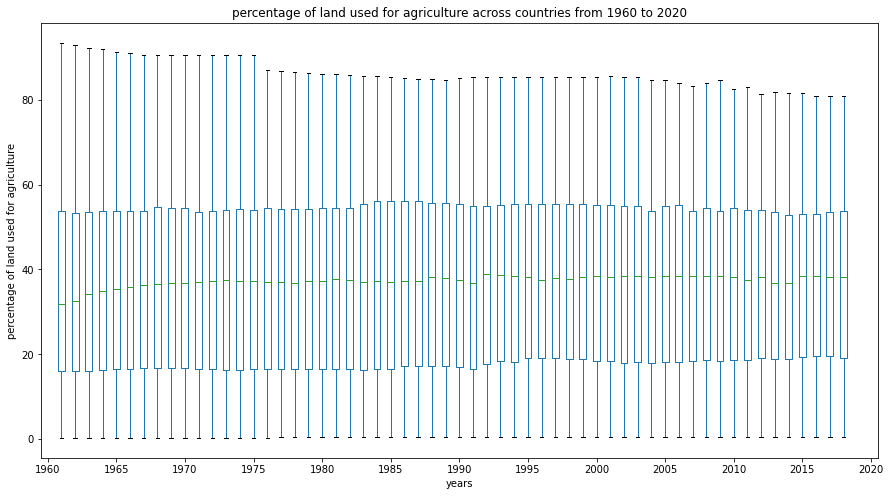

In [56]:
eda_year_boxplots(df_wb[['country','year','agri_pc']])

The median percentage of land area used for agriculture across countries has increased from 1961 to 2018 (overall increasing trend), which is consistent with the overall increase in agricultural area.

The interquartile range has remained quite similar while the range has decreased (the maximum has decreased more than the minimum increased). Perhaps in countries that already had a lot of agricultural area, the pressures of being forced to clear land space for other aspects of countries' development were greater than the pressures of increasing demand for agricultural products.

The boxplots seemed to suggest slight right-skewness in the first few years but in more recent years, the distribution across countries tends to be somewhat symmetrical. This is consistent with the overall increase in agricultural area (mean percentage of a country's land area used for agriculture has increased).

There are no outliers.

###### Value of food production In Singapore
We also make plots (line/donut chart) to analyse the value of various types of food production in Singapore (which is likely to be related to the amount of each type of food produced) over the past few years.

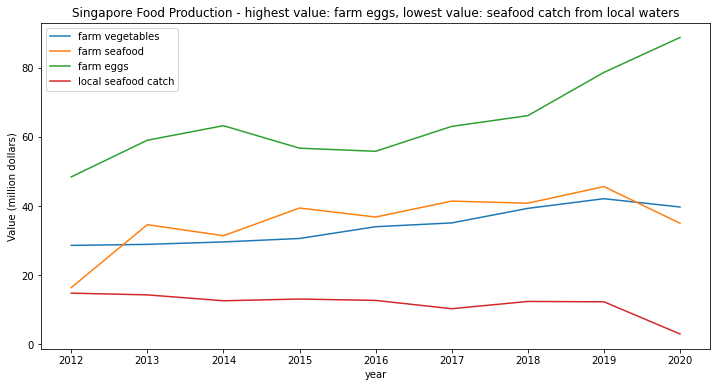

In [57]:
def eda_q1a_lineplot():
    df_prod_value_sg.plot(figsize=(12,6))
    plt.title('Singapore Food Production - highest value: farm eggs, lowest value: seafood catch from local waters')
    plt.ylabel('Value (million dollars)')

eda_q1a_lineplot()

The initial rankings were the same as the final rankings (lowest value of local seafood catch, followed by farm seafood, then farm vegetables and highest value of farm eggs). However, for most of the years (2013 to 2019), farm seafood had higher value than farm vegetables.

Overall, the value of farm eggs has increased substantially from around 50 million dollars in 2012 to above 80 million dollars in 2020. The value of farm seafood has increased from slightly less than 20 million dollars to slightly more than 30 million dollars, while the value of farm vegetables has increased less than farm seafood, from around 30 million dollars to slightly less than 40 million dollars. The value of local seafood catch, however, has decreased from less than 20 million dollars in 2012 to less than 10 million dollars in 2020.

This could be due to the increasing support for local _farm_ produce, due to more awareness and campaigns over recent years. For example, the "30 by 30" campaign for Singapore to produce 30% of its food consumption by 2030 was announced in 2019, which led to the increase in value of local produce in 2019. This increase continued in 2020 for farm eggs but decreased for the other categories, and we suggest that one possible cause could be disruptions in the food supply chain and consumer habits during the COVID-19 pandemic.

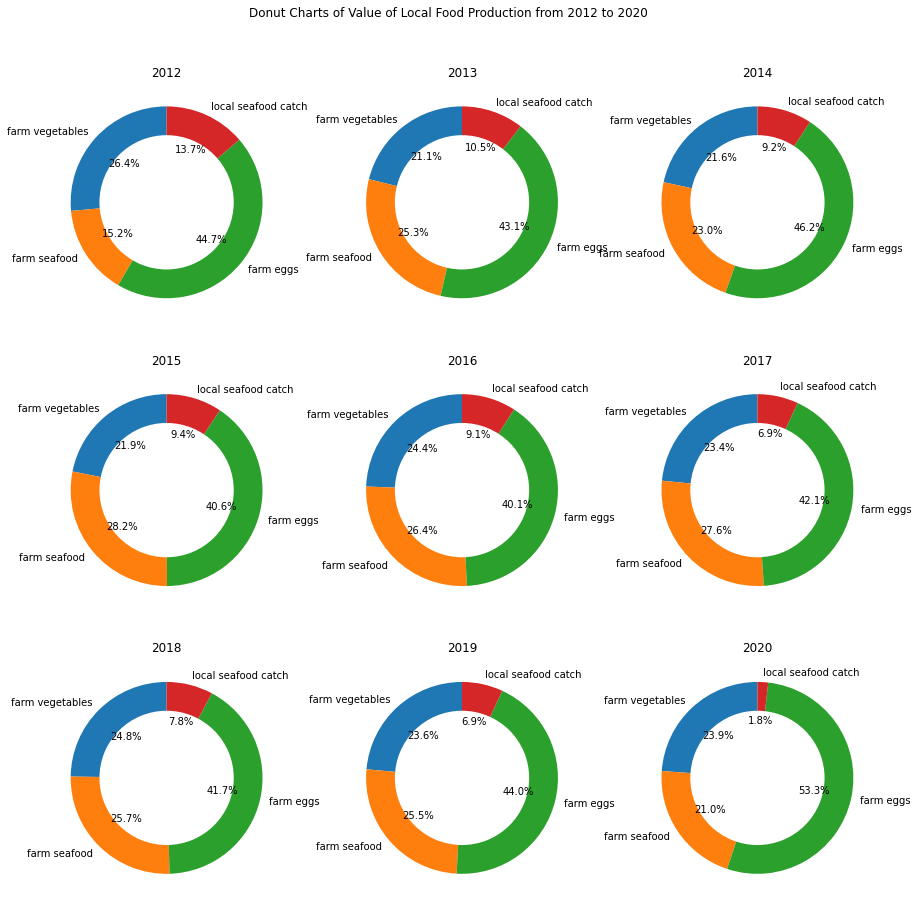

In [58]:
def eda_q1a_donut():
    fig, axs = plt.subplots(3,3,figsize=(15,15))
    fig.suptitle('Donut Charts of Value of Local Food Production from 2012 to 2020',y=0.95)
    for r in range(3):
        for c in range(3):
            axs[r,c].pie(df_prod_value_sg.T[2012+3*r+c], labels = df_prod_value_sg.T[2012+3*r+c].index,
                         shadow=False, startangle=90, autopct='%1.1f%%')
            axs[r,c].set_title(str(2012+3*r+c))
            axs[r,c].pie([1],radius=0.7,colors=['white']) # donut
    plt.show()

eda_q1a_donut()

Local seafood catch had the largest change (decrease), from 13.7% of the total to 1.8% of the total value. Farm seafood had the largest increase, from 15.2% of the total to 21.0% of the total value. This could be because of the increased emphasis on local farm produce resulting in more fishers contributing to farms rather than catching whatever seafood comes by in local waters.

Farm eggs have increased in value from 44.7% to 53.3% of the different types of food production, and farm vegetables have decreased slightly from 26.4% to 23.9%.

###### B. Across various countries? <a id='1b'/>
We plot choropleth maps to visualise how the geography of various countries might affect the amount of agricultural land and aquaculture production. (e.g. land-locked countries vs countries near the coast, or differences across continents)

In [59]:
def draw_map(df, ylabel, legend):
    world_map = folium.Map(location=[0,0],zoom_start=1)
    folium.Choropleth(
        geo_data=world_geo,
        data=df,
        columns=['country',ylabel],
        key_on='feature.properties.name',
        fill_color='YlGn',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name=legend
    ).add_to(world_map)
    return world_map

In [60]:
def eda_q1b_map(y, start_year, end_year):
    if start_year > end_year:
        return 'Error: end year cannot be before start year'
    ylabel = y.title().lower()
    years_label = ''
    if start_year==end_year:
        years_label = ' in ' + str(start_year)
    else:
        years_label = ' from ' + str(start_year) + ' to ' + str(end_year)
        
    df_plot = df_wb.loc[(df_wb.year>=start_year)&(df_wb.year<=end_year)&(df_wb.country!='World')].copy()
    df_plot = df_plot.set_index('country').pivot(columns='year')[ylabel].mean(axis=1)
    
    return draw_map(df_plot, ylabel, 'Mean ' + label_dict[ylabel] + years_label)

interact(eda_q1b_map,
         y=widgets.Dropdown(options=list(df_wb.select_dtypes('float64').columns[2:5]),description='y-axis'),
         start_year=widgets.IntSlider(min=1960,max=2020,step=1,value=1960,description='start year'),
         end_year=widgets.IntSlider(min=1960,max=2020,step=1,value=2020,description='end year'))

interactive(children=(Dropdown(description='y-axis', options=('agri', 'agri_pc', 'aqua'), value='agri'), IntSl…

<function __main__.eda_q1b_map(y, start_year, end_year)>

###### Mean agricultural area
1960 to 2020: Alaska, the US, China and Australia have the greatest mean agricultural area from 1960 to 2020. Brazil, Russia, Kazakhstan and India have the next few greatest mean agricultural areas.

1960 to 1991: This plot clearly reveals the lack of data for Russia, Kazakhstan and other neighbouring countries (large grey area), thus allowing us to come to the conclusions stated earlier in Q1A. The 4 countries with the greatest mean agricultural area remain the same, and Brazil and India also still remain as the countries with the next few greatest mean agricultural areas.

1992 to 2020: China has the greatest mean agricultural area, followed by Alaska, the US and Australia. This suggests that China's agricultural area may have been increasing more rapidly than the other countries.

1961 and 2018 (earliest and latest year with some non-`NaN` data points, respectively): Indeed, the deduction obtained from 1992 to 2020 is consistent with observations for this section - Alaska, the US and Australia have the greatest mean agricultural area in 1961, with China as the next greatest, while China has the greatest mean agricultural area in 2018, with the other 3 countries as the next greatest. Since the total agricultural area for each of these 4 countries across all the years should be quite similar (hence grouped in the same colour when viewing the 1960-2020 plot), smaller values for China in the beginning and larger values later on suggest that China's agricultural area has been increasing at a faster rate than the other countries.

###### Mean percentage of land area used for agriculture
1960 to 2020: the countries with the highest percentage of land area used for agriculture appear to be located primarily in Europe, Asia and Africa (and there is one country in South America, Uruguay). Only about 2 of these countries are landlocked.

Comparing 1961 to 2018, the green shades are generally darker in 2018 than in 1961, suggesting an overall increase of percentage of land area used for agriculture (as the scale has not changed very significantly). Notably, Saudi Arabia changed from the third lightest shade of green to the darkest shade of green. However, overall most parts of the map still appear similar.

###### Mean aquaculture production
1960 to 2020: China is a clear outlier - it is the only country of the darkest shade of green and all the other countries are the lightest shade of green.

This could partially be due to higher demand for seafood in China compared to other parts of the world. According to [Wikipedia](https://en.wikipedia.org/wiki/Aquaculture_in_China), China, with one-fifth of the world's population, accounts for two-thirds of the world's reported aquaculture production. In 2003, the global per capita consumption of fish was estimated at 16.5 kg, with Chinese consumption estimated at 25.8 kg. Since 2002, China has been the world's largest exporter of fish and fish products. In 2005, exports of aquaculture products from China were valued at 7.7 billion USD, with Japan, the United States and South Korea as the main markets; China was also the sixth largest importer of fish and fish products in the world, with imports totalling 4.0 billion USD.

1961 (earliest year with some non-`NaN` data points): Besides China, the Philippines is the other country that is not the lightest shade of green (second lightest).

2018 (latest year with some non-`NaN` data points): Besides China, Indonesia is the other country that is not the lightest shade of green (second lightest).

We do more analysis on the aquaculture production, _excluding_ China's data from the map.

In [61]:
df_plot = df_wb.loc[(df_wb.year>=1960)&(df_wb.year<=2020)&(df_wb.country!='World')&(df_wb.country!='China')].copy()
df_plot = df_plot.set_index('country').pivot(columns='year')[ylabel].mean(axis=1)
draw_map(df_plot, ylabel, 'Mean ' + label_dict[ylabel] + ' from 1960 to 2020 excluding China')

The other countries that have high amounts of aquaculture production are Alaska, the US and Australia. These are the same countries that had high amounts of agriculture, and the map looks quite similar to the map for agricultural area from 1960 to 2020. This suggests a possible correlation between agriculture and aquaculture, which might be due to factors such as certain countries being major exporters of food or having greater demand for certain foods.

###### C. In relation to GDP?
We draw pairplots of agricultural area, aquaculture production and GDP per capita where each point represents a different country.

In [62]:
def eda_q1cd_pairplot(year, exclude, ylabel):
    mask = df_wb.year==year
    for c in exclude:
        mask = mask&(df_wb.country!=c)
    df = df_wb.loc[mask,[ylabel,'agri','agri_pc','aqua']].copy()
    df.columns=[ylabel,'agri','agri_pc','aqua']
    g = sns.pairplot(df.dropna(axis=0),plot_kws={'alpha':0.5})
    g.fig.suptitle('Pairplot for food production and ' + label_dict[ylabel] + ' across countries in ' + str(year),y=1.01)

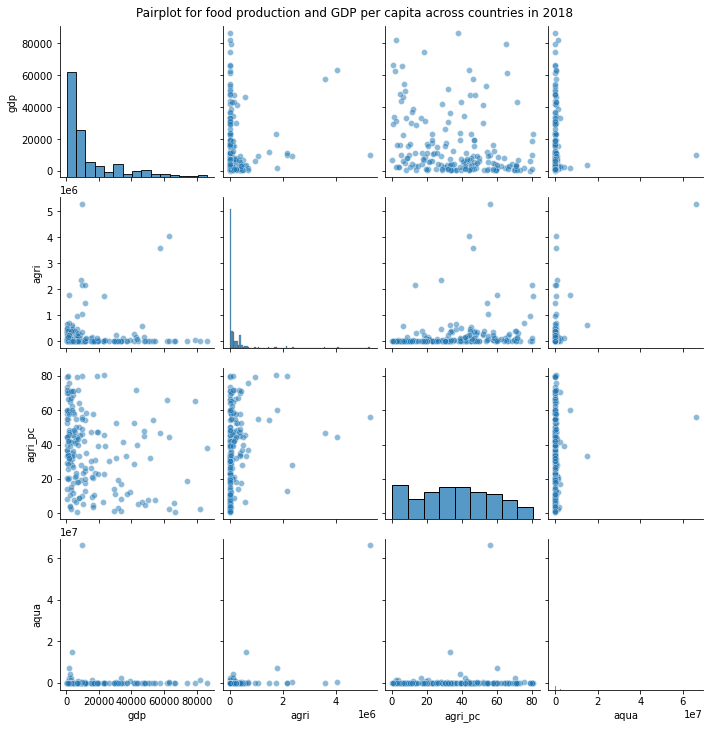

In [63]:
eda_q1cd_pairplot(2018, ['World'], 'gdp')

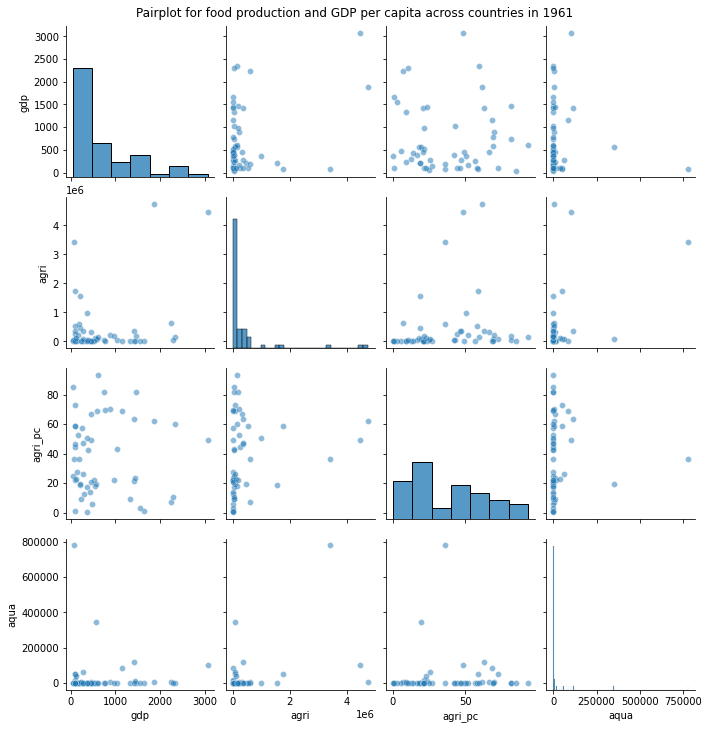

In [64]:
eda_q1cd_pairplot(1961, ['World'], 'gdp')

The scatterplots showing GDP against the other three variables appear to have quite similar distribution in both 1961 and 2018, which suggests the relationship between GDP and food production has not changed much over the years.

These are unlikely to be linear relationships, however, as there are many outliers for agricultural area and aquaculture production, and meanwhile the points in the scatterplot of GDP against percentage land used for agriculture seem to be quite randomly placed. There are likely other factors across the different countries that are related to food production.

We also draw regression plots for the worldwide agricultural area and aquaculture production against GDP per capita (over time, i.e. each point represents a different year), and calculate the Pearson correlation.

In [65]:
def eda_q1cd_regplot(ax, start_year, end_year, xlabel, ylabel):
    title = 'Worldwide ' + ylabel + ' vs ' + xlabel + ' from ' + str(start_year) + ' to ' + str(end_year)
    mask=(df_wb.country=='World')&(df_wb.year>=start_year)&(df_wb.year<=end_year)
    mask=mask&(df_wb[xlabel].notna())&(df_wb[ylabel].notna())
    print(title + ": " + str(stats.pearsonr(df_wb.loc[mask,xlabel],df_wb.loc[mask,ylabel])))
    sns.regplot(x=xlabel, y=ylabel, data=df_wb.loc[mask],ax=ax)
    ax.set_xlabel(label_dict[xlabel])
    ax.set_ylabel(label_dict[ylabel])
    ax.set_title(title)

Worldwide agri vs gdp from 1961 to 2020: (0.892815758390515, 4.741975415178149e-21)
Worldwide agri vs gdp from 1961 to 1991: (0.9583542990244773, 2.5143563547370094e-17)
Worldwide agri vs gdp from 1992 to 2020: (0.6076385953280146, 0.000774695239042339)
Worldwide aqua vs gdp from 1961 to 2020: (0.9735308582705626, 1.1899808759809402e-35)


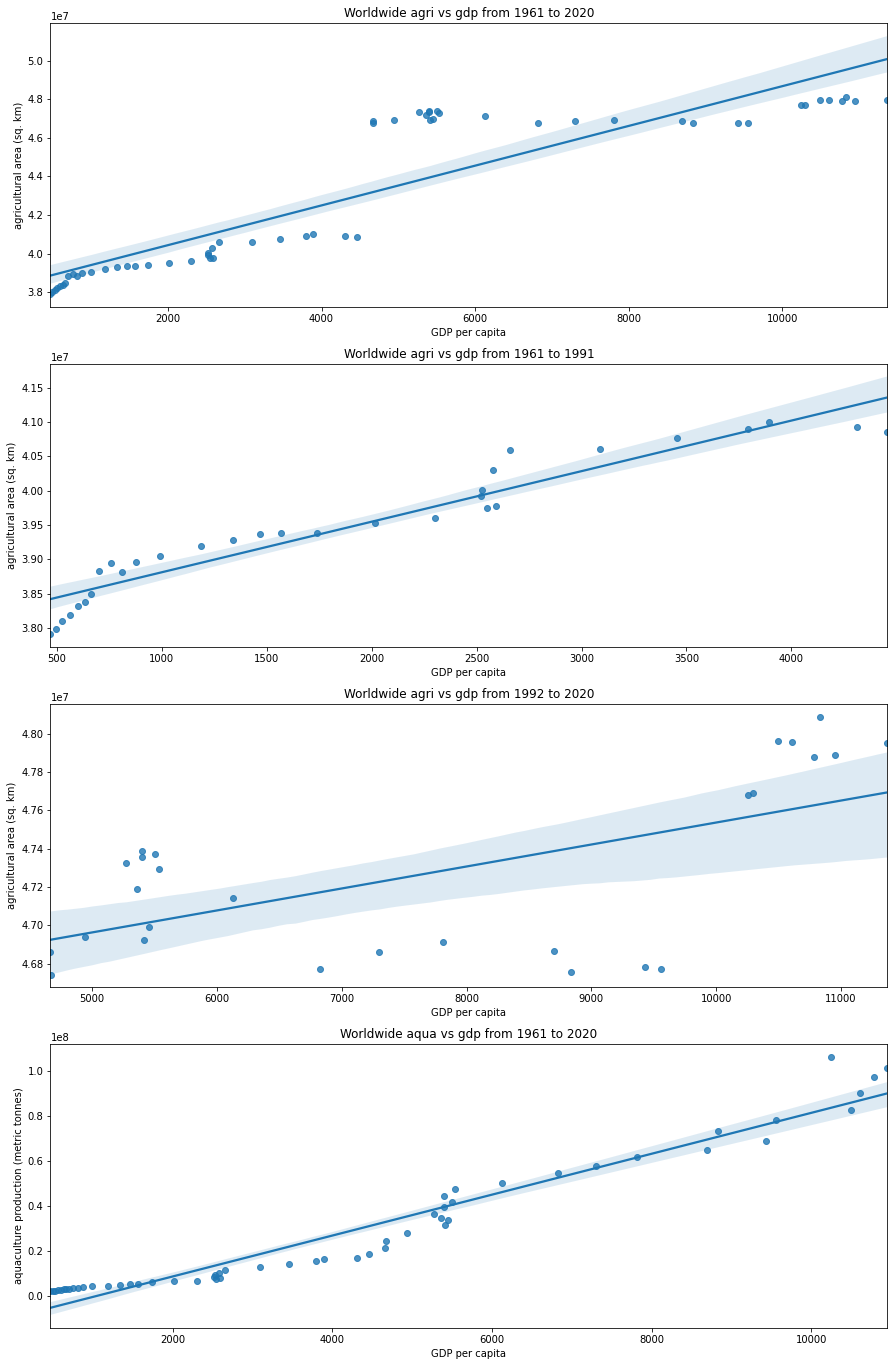

In [66]:
def eda_q1c_regplot():
    fig, axs = plt.subplots(4,1,figsize=(15,24))
    eda_q1cd_regplot(axs[0], 1961, 2020, 'gdp', 'agri')
    eda_q1cd_regplot(axs[1], 1961, 1991, 'gdp', 'agri')
    eda_q1cd_regplot(axs[2], 1992, 2020, 'gdp', 'agri')
    eda_q1cd_regplot(axs[3], 1961, 2020, 'gdp', 'aqua')

eda_q1c_regplot()

Comparing the worldwide values over time, we can see more positive linear relationships - the strongest being between GDP and aquaculture production (coefficient ~0.97), followed by agricultural area from 1961 to 1991 (coefficient ~0.96), then agricultural area from 1961 to 2020 (coefficient ~0.89) and lastly agricultural area from 1992 to 2020 (coefficient ~0.61).

Hence we conclude that food production is positively correlated with GDP per capita worldwide.

###### D. In relation to population size?
We draw pairplots of agricultural area, aquaculture production and population size where each point represents a different country.

China and India's population sizes are extreme outliers, so they will be removed.

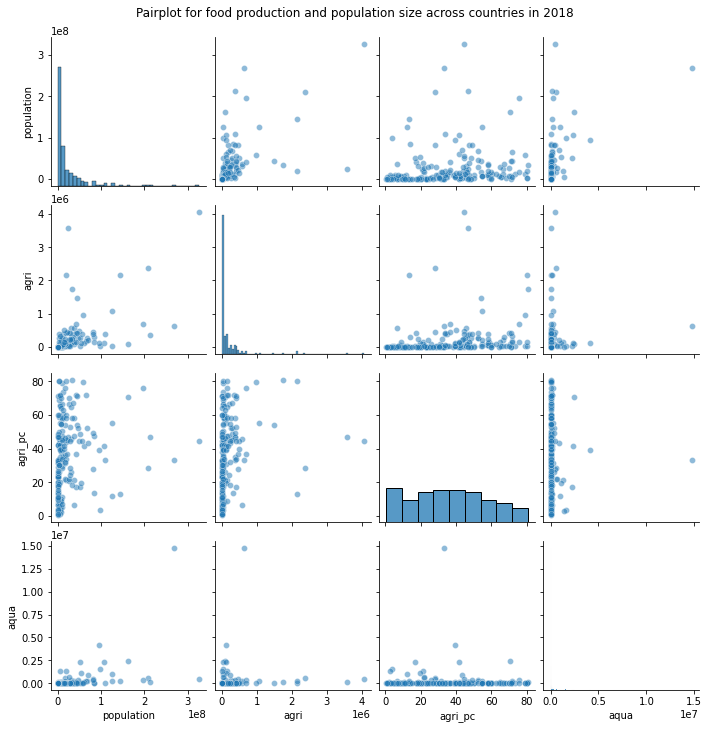

In [67]:
eda_q1cd_pairplot(2018, ['World','China','India'], 'population')

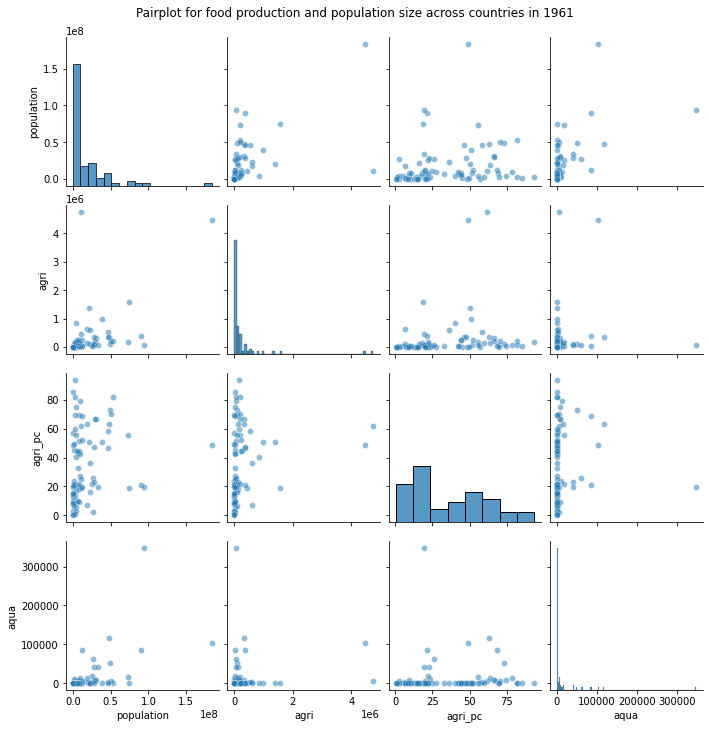

In [68]:
eda_q1cd_pairplot(1961, ['World','China','India'], 'population')

The scatterplots showing population size against the other three variables appear to have quite similar distribution in both 1961 and 2018, which suggests the relationship between population size and food production has not changed much over the years.

These are unlikely to be linear relationships as there are many outliers for agricultural area and aquaculture production, and meanwhile the points in the scatterplot of population size against percentage land used for agriculture seem to be quite randomly placed. However, the outliers for population size appear to be "nearer" than for GDP (i.e. we can see slightly more of the spread of the remaining points), other than China and India (not shown in the plots).

There are likely other factors across the different countries that are related to food production.

We also draw regression plots for the worldwide agricultural area and aquaculture production against population size (over time, i.e. each point represents a different year), and calculate the Pearson correlation.

Worldwide agri vs population from 1961 to 2020: (0.9351263162155073, 6.60311726782257e-27)
Worldwide agri vs population from 1961 to 1991: (0.9918958804163086, 1.5342746054082166e-27)
Worldwide agri vs population from 1992 to 2020: (0.6436449493605055, 0.000292171531554998)
Worldwide aqua vs population from 1961 to 2020: (0.9218148208265254, 1.810829821843624e-23)


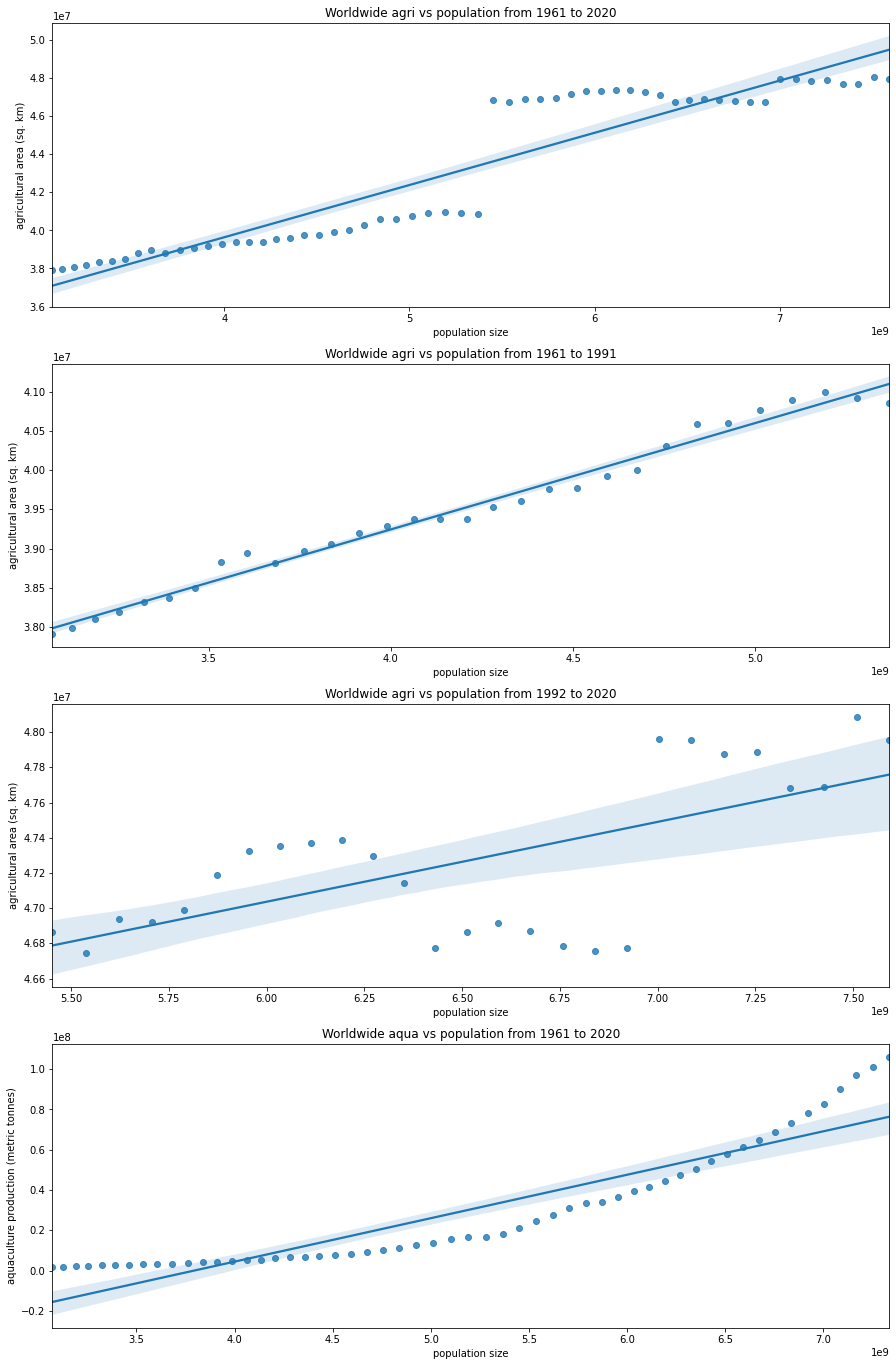

In [69]:
def eda_q1d_regplot():
    fig, axs = plt.subplots(4,1,figsize=(15,24))
    eda_q1cd_regplot(axs[0], 1961, 2020, 'population', 'agri')
    eda_q1cd_regplot(axs[1], 1961, 1991, 'population', 'agri')
    eda_q1cd_regplot(axs[2], 1992, 2020, 'population', 'agri')
    eda_q1cd_regplot(axs[3], 1961, 2020, 'population', 'aqua')

eda_q1d_regplot()

Comparing the worldwide values over time, we can see more positive linear relationships - the strongest being between population size and agricultural area from 1961 to 1991 (coefficient ~0.99), followed by agricultural area from 1961 to 2020 (coefficient ~0.94), then aquaculture production (coefficient ~0.92), and lastly 1992 to 2020 (coefficient 0.64).

Hence we conclude that food production is positively correlated with population size worldwide.

We have reason to believe that agricultural area is actually more correlated to GDP and population size than it seems from the 1961 to 2020 plots, as we know that the reason for the sudden increase between 1991 and 1992 is incomplete data.

##### Q2<a id='ex2'/>
###### How are the amounts of agriculture and aquaculture related?

For worldwide data as well as various countries, we draw a jointplot of aquaculture production against the area used for agriculture, where each point is a different year.

We choose a jointplot so that we can view the trend of agriculture against aquaculture together with the individual histograms for each variable.

In [70]:
# each point is a different year
def eda_q2_scatter_helper(ax, country, start_year, end_year):
    df = df_wb.loc[(df_wb.country==country)&(df_wb.year>=start_year)&(df_wb.year<=end_year),['agri','aqua']].copy()
    df.dropna(axis=0,how='any',inplace=True)
    title = country + ' aquaculture against agriculture from ' + str(start_year) + ' to ' + str(end_year)
    print(title + ': ' + str(stats.pearsonr(df.agri,df.aqua)))
    
    df.plot(kind='scatter',x='agri',y='aqua',alpha=0.5, ax=ax)
    ax.set_xlabel(label_dict['agri'])
    ax.set_ylabel(label_dict['aqua'])
    ax.set_title(title)

World aquaculture against agriculture from 1960 to 2020: (0.8536907998197434, 1.2196842884621805e-16)
World aquaculture against agriculture from 1960 to 1991: (0.9506187990927024, 2.829135142733173e-16)
World aquaculture against agriculture from 1992 to 2020: (0.5661742777788799, 0.003926076027707048)
Singapore aquaculture against agriculture from 1960 to 2020: (-0.8366409667784114, 2.8900246248055854e-16)
United States of America aquaculture against agriculture from 1960 to 2020: (-0.8510310485833588, 2.6755908093136832e-17)
United Kingdom aquaculture against agriculture from 1960 to 2020: (-0.8518485448295778, 2.3199347164516282e-17)
China aquaculture against agriculture from 1960 to 2020: (0.7630581658581406, 3.3385927933173454e-12)
India aquaculture against agriculture from 1960 to 2020: (0.22510743446907466, 0.08933256097118544)


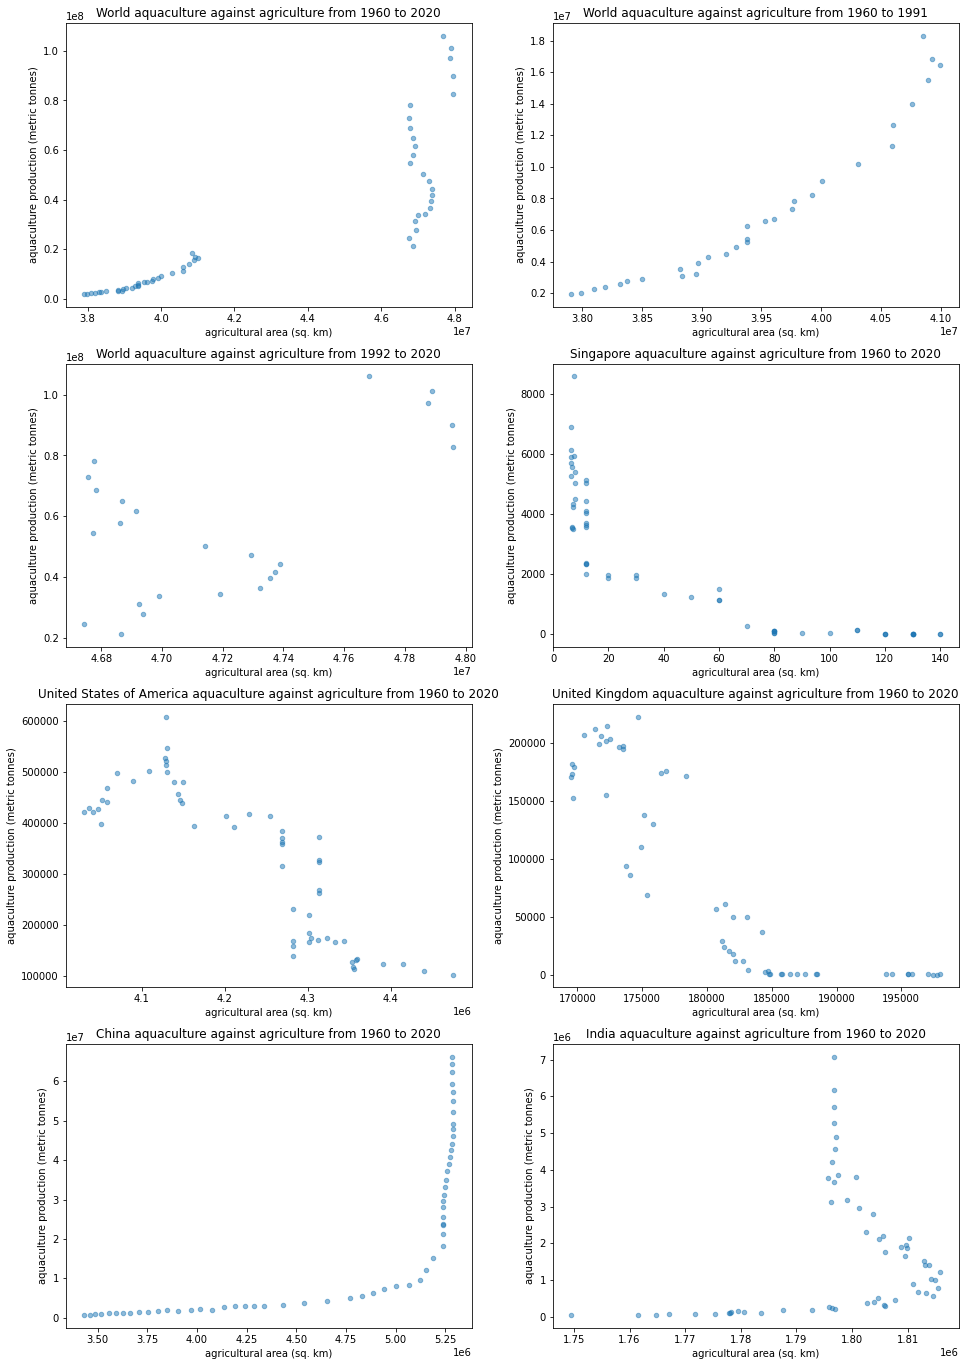

In [71]:
def eda_q2_scatter():
    fig, axs = plt.subplots(4,2,figsize=(16,24))
    eda_q2_scatter_helper(axs[0,0],'World',1960,2020)
    eda_q2_scatter_helper(axs[0,1],'World',1960,1991)
    eda_q2_scatter_helper(axs[1,0],'World',1992,2020)
    eda_q2_scatter_helper(axs[1,1],'Singapore',1960,2020)
    eda_q2_scatter_helper(axs[2,0],'United States of America',1960,2020)
    eda_q2_scatter_helper(axs[2,1],'United Kingdom',1960,2020)
    eda_q2_scatter_helper(axs[3,0],'China',1960,2020)
    eda_q2_scatter_helper(axs[3,1],'India',1960,2020)

eda_q2_scatter()

**Worldwide 1960 to 1991:** There is a strong positive linear relationship according to the correlation coefficient (~0.95, p-value <<0.01), so a larger agricultural area is correlated with more aquaculture production.

The scatterplot of aquaculture vs agriculture seems to show an increasing trend with slightly increasing gradient. Since Q1A shows that both the agricultural area and aquaculture production have been generally increasing from 1960 to 1991, this suggests aquaculture production is increasing slightly faster than land area used for agriculture.

One possible reason is aquaculture developing slightly faster than agriculture worldwide from 1960 to 1991, which might be due to the restrictions in land area as a result of urbanisation in many parts of the world, resulting in people looking towards other food sources such as the sea.

Alternatively, research and development in technologies to enhance food production could also have played a role in both agriculture and aquaculture. In the case of agriculture, with innovations such as vertical farming, the agricultural land might have increased at a slower rate than agriculture production (that is, _agricultural land may not be a very good indicator of agriculture production_); in the case of aquaculture, technology, such as methods to improve water quality, could have contributed to the increase in aquaculture production. In this case, we cannot comment on the rate of development of agriculture and aquaculture themselves.

**Worldwide 1992 to 2020:** There does not seem to be any clear relationship between the two variables in the more recent years from 1992 to 2020, according to the correlation coefficient (~0.57, p-value <0.01) and the scatterplot. There appear to be two different clusters of data. It is possible that there were other factors, such as data points being added/removed that caused relatively large changes in the values.

**Singapore 1960 to 2020:** As shown in Q1A, Singapore's agricultural area has been decreasing over the years while aquaculture has been on a general increasing trend, so a somewhat negative relationship is not very surprising. We venture a guess that as agriculture declined over the years due to lack of land space during urbanisation, Singapore found other possible food sources such as local fish farms to increase local food supply.

**US and UK 1960 to 2020:** The situation in the US and the UK appear somewhat similar to Singapore (weak negative linear correlation) because the agricultural area has been generally decreasing while aquaculture has been generally increasing (by varying amounts). However, the distribution of each variable appears slightly less skewed than in Singapore - the points seem to be distributed slightly more closely to a somewhat linear trend, and the magnitude of the correlation coefficients are higher than for Singapore. Similarly to Singapore, we suspect the trend declining agriculture and increasing aquaculture may be related to becoming more developed/urban.

**China 1960 to 2020:** Based on Q1A, China had very little increase in agricultural area in the last few years and very little increase in the aquaculture production in the first few years.

**India 1960 to 2020:** Based on Q1A, there was little increase in aquaculture production in the first few years, while the agricultural area increased, then decreased slightly to a plateau. This pattern is somewhat similar to that in China.

For China and India, the patterns in the scatterplot arise because the increase in agriculture preceded the increase in aquaculture, and the individual distributions of data points are such that agriculture is left-skewed while aquaculture is right-skewed. This also indicates that aquaculture may be more likely to develop than agriculture in a more developed society.

Overall, the trends across different countries appear to vary due to the different conditions and requirements of the different countries.

To compare across countries, we also draw a jointplot of aquaculture production against agricultural area in a specific year, where each point represents a different country, to see if amount of aquaculture correlates with agriculture across countries.

We draw a jointplot so that we can also analyse the distribution of each individual variable across different countries.

In [72]:
# each point is a different country
def eda_q2_jointplot_country(year, xlim, ylim):
    df = df_wb.loc[(df_wb.country!='World')&(df_wb.year==year),['country','agri','aqua']].copy()
    df.dropna(axis=0,how='any',inplace=True)
    mask = (df.agri>=xlim)|(df.aqua>=ylim)
    print(df[mask]) # print the outliers
    df = df.loc[~mask] # remove the outliers
    title = 'aquaculture against agriculture in ' + str(year)
    print(title + ": " + str(stats.pearsonr(df.agri,df.aqua)))
    plt.figure(figsize=(12,6))
    
    g = sns.jointplot(x='agri', y='aqua', data=df, height=12, kind='reg')
    g.set_axis_labels(xlabel=label_dict['agri'],ylabel=label_dict['aqua'])
    g.fig.suptitle(title,y=1.05)

Empty DataFrame
Columns: [country, agri, aqua]
Index: []
aquaculture against agriculture in 2018: (0.5853024021819232, 4.847508650058251e-19)


<Figure size 864x432 with 0 Axes>

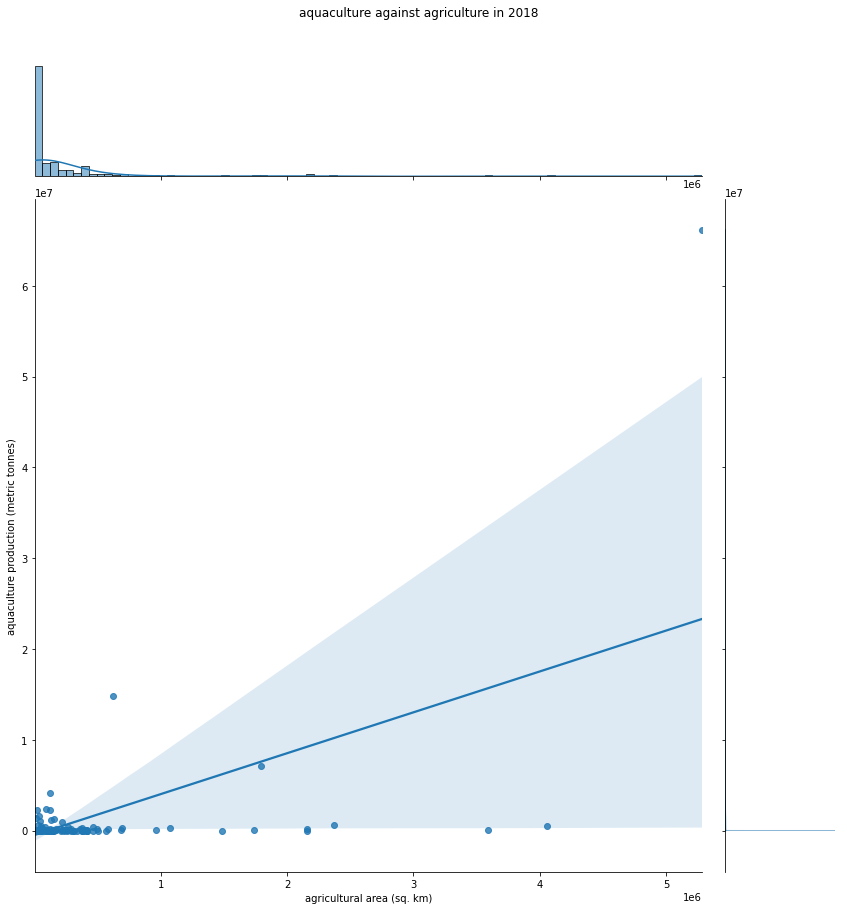

In [73]:
eda_q2_jointplot_country(2018,1000000000,1000000000)

Some outlier values are removed (only points with `x < xlim` and `y < ylim` are used) so that we can observe the data more clearly.

                        country         agri          aqua
12708                 Argentina  1487680.000  3.205310e+03
12712                 Australia  3588950.000  9.679852e+04
12719                Bangladesh    92023.000  2.405416e+06
12728                    Brazil  2368788.010  6.057300e+05
12737                     Chile   156930.000  1.287232e+06
12738                     China  5285287.000  6.613506e+07
12760                     Egypt    38359.688  1.561457e+06
12790                 Indonesia   623000.000  1.477210e+07
12792                     India  1796740.000  7.071302e+06
12801                     Japan    44200.000  1.032675e+06
12802                Kazakhstan  2160365.000  1.600000e+03
12808               South Korea    16520.000  2.278850e+06
12828                    Mexico  1068910.000  2.472224e+05
12833                   Myanmar   128890.000  1.131706e+06
12848                    Norway     9862.970  1.355117e+06
12856               Philippines   124400.000  2.304361e+

<Figure size 864x432 with 0 Axes>

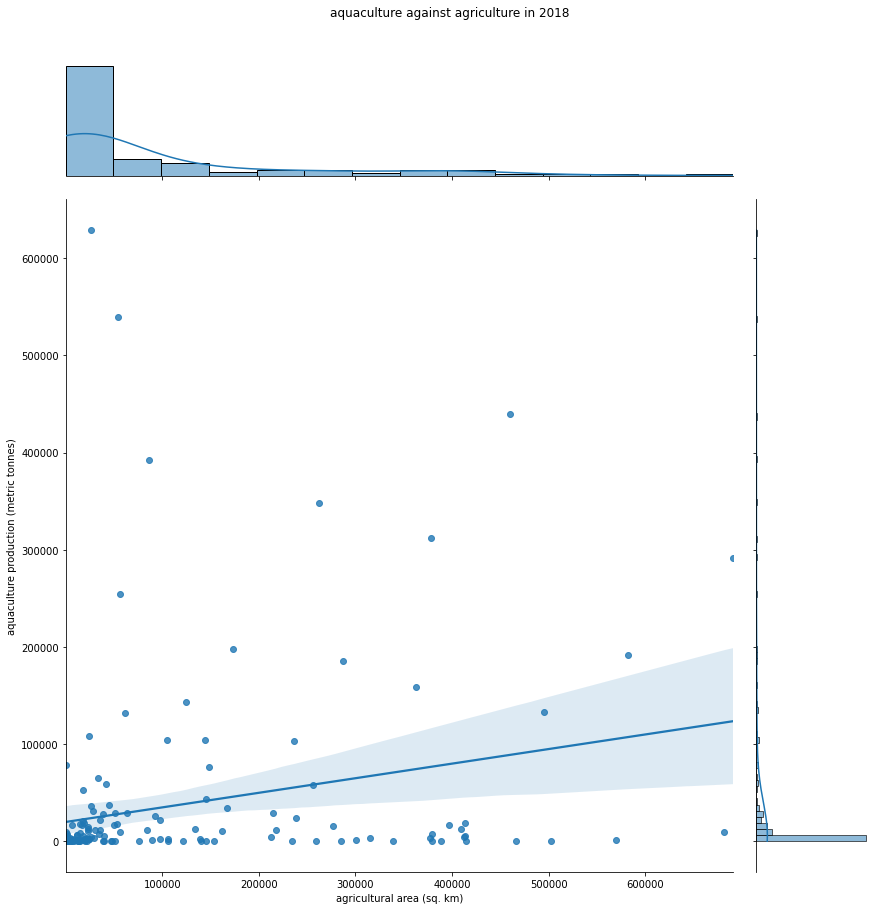

In [74]:
eda_q2_jointplot_country(2018,800000,800000)

Despite removing the extremely large outliers, the correlation between the two variables is very weak and hence we conclude there is no correlation between aquaculture production and agricultural land across different countries.

The countries with top 3 aquaculture production are China, Indonesia and India, among which China has the most and Indonesia has the least agricultural land area. The countries with top 3 agricultural land are China, the US and Australia, among which China has the most and Australia has the least aquaculture production.

Notably, Norway has the least agricultural area among the outliers but very high aquaculture production, which is understandable as it is one of the Scandinavian countries which are known for seafood.

Kazakhstan has the least aquaculture production among the outliers but very high agricultural area, which also makes sense as it is the world's largest land-locked country (it shares a small boundary with a water body that is surrounded by land).

#### Food Trade<a id='extrade'/>
##### Q3<a id='ex3'/>
Define the net food trade as (money equivalent to food imports) - (money equivalent to food exports). (net amount of food brought into the country, in terms of money)

In [75]:
df_wb['net_trade'] = df_wb.food_in - df_wb.food_out
df_wb.head(3)

,country,year,population,gdp,agri,agri_pc,aqua,food_in,food_out,net_trade
0,Aruba,1960,54208.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1960,8996967.0,59.773234,NaN,NaN,NaN,NaN,NaN,NaN
2,Angola,1960,5454938.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


How do food imports and exports change:

###### A. Over the years?
We draw point plots of the amount of money equivalent to food imports and food exports, against time, worldwide and for various countries.

In [76]:
def year_pointplot(y,data,figsize,ylabel,title,hue=None):
    plt.figure(figsize=figsize)
    sns.pointplot(x='year',y=y,hue=hue,data=data)
    plt.xticks(ticks=np.arange(0,len(data['year'].unique()),5))
    plt.xlabel('years')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

In [77]:
def eda_q3a_pointplot(y, country):
    if len(country)==0:
        return 'Please select at least one country'
    ylabel = y.title().lower()
    mask = df_wb.country==country[0]
    for c in country:
        mask = mask|(df_wb.country==c)
    h=6
    if len(country)>1:
        h=18
    year_pointplot(df_wb.loc[mask,ylabel], df_wb.loc[mask], (15,h), label_dict[ylabel],
                label_dict[ylabel]+' from 1960 to 2020 in '+str(country), hue='country')

print('You can select multiple countries.')
interact(eda_q3a_pointplot,
         y=widgets.Dropdown(options=list(df_wb.select_dtypes('float64').columns[5:8]),description='y-axis'),
         country=widgets.SelectMultiple(options=countries,value=['Singapore','United States of America','United Kingdom','China','India']))

You can select multiple countries.


interactive(children=(Dropdown(description='y-axis', options=('food_in', 'food_out', 'net_trade'), value='food…

<function __main__.eda_q3a_pointplot(y, country)>

###### Food imports
**Worldwide:** overall increasing trend, with sharper increase starting from the early 2000s. There is a gap in the data in 1988.

**Countries:** All of the food imports have been increasing over the years. As of 2018, the US has the highest food imports, followed by China, then the UK, India and finally Singapore. In 1961, the UK had slightly more food imports than the US, and India had slightly more food imports than Singapore, where the UK and US had more food imports than India and Singapore. Notably, China's food imports exceeded the UK's in 2010, and the US had the highest food imports ever since overtaking the UK in 1966. Also, Singapore had overtaken India from around 1977 to 2007.

###### Food exports
**Worldwide:** overall increasing trend, with sharper increase starting from the early 2000s. There is a gap in the data from 1988 to 1990.

**Countries:** All of the food exports have been increasing over the years. The US was clearly consistently exporting the most food. In 1961, Singapore exported the least food, followed by India and then the UK, but all of these values were very close and notably lower than that of the US. In 2018, Singapore still exported the least food, with the UK exporting more than double the value of Singapore, India exporting slightly more than the UK, China exporting close to double the value of India and the US exporting more than double the value of China. Notably, China overtook the UK in 2001.

###### Net food trade
**Worldwide:** Net food trade takes a negative value more often than not, indicating that the value of food exports tends to be larger than that of food imports. The only time it went significantly more than 0 was from 2000-2005.

**Countries:** The US almost consistently exporting significantly more than it imports. Meanwhile, China has been importing significantly more than it exports in recent years (2008 onwards). Singapore appears to have been importing more than it exports until recent years (2017-2018), while India and the US have been exporting more than it exports and the UK has always been importing more than it exports.

###### B. In relation to food production, GDP and population size?
We draw subplots of scatterplots for agricultural area, aquaculture production, GDP per capita, population size against amount of money equivalent to food imports, food exports and net food trade, where each point represents a different country.

In [78]:
def eda_q3b_scatterplot(ax, year, exclude, y, x):
    mask = df_wb.year==year
    for c in exclude:
        mask = mask&(df_wb.country!=c)
    df = df_wb.loc[mask,[x,y]].copy()
    df.plot(kind='scatter', alpha=0.5, x=x, y=y, ax=ax)

In [79]:
def eda_q3b_subplots(year):
    fig, axs = plt.subplots(4,3,figsize=(15,15))
    fig.suptitle('Scatterplots for agricultural area, aquaculture production, GDP and population size against food trade in ' + str(year), y=0.9)
    ylabel = ['agri','aqua','gdp','population']
    xlabel = ['food_in','food_out','net_trade']
    for r in range(4):
        for c in range(3):
            if r<3:
                eda_q3b_scatterplot(axs[r,c], year, ['World'], ylabel[r], xlabel[c])
            else:
                eda_q3b_scatterplot(axs[r,c], year, ['World','China','India'], ylabel[r], xlabel[c])

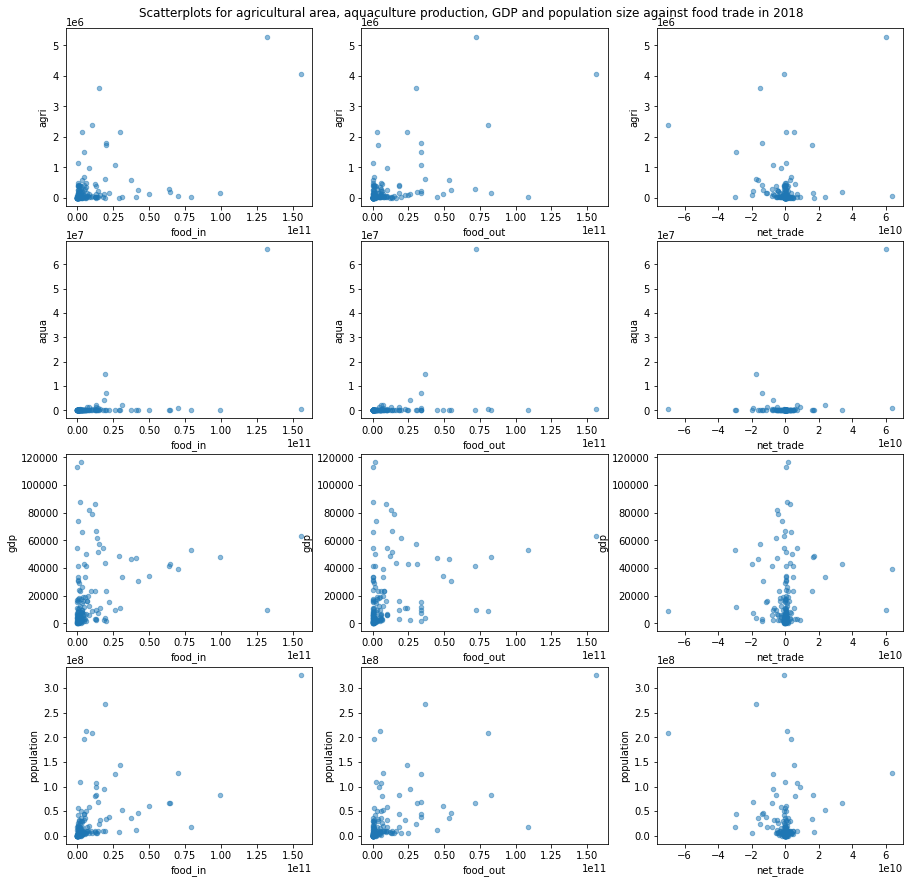

In [80]:
eda_q3b_subplots(2018)

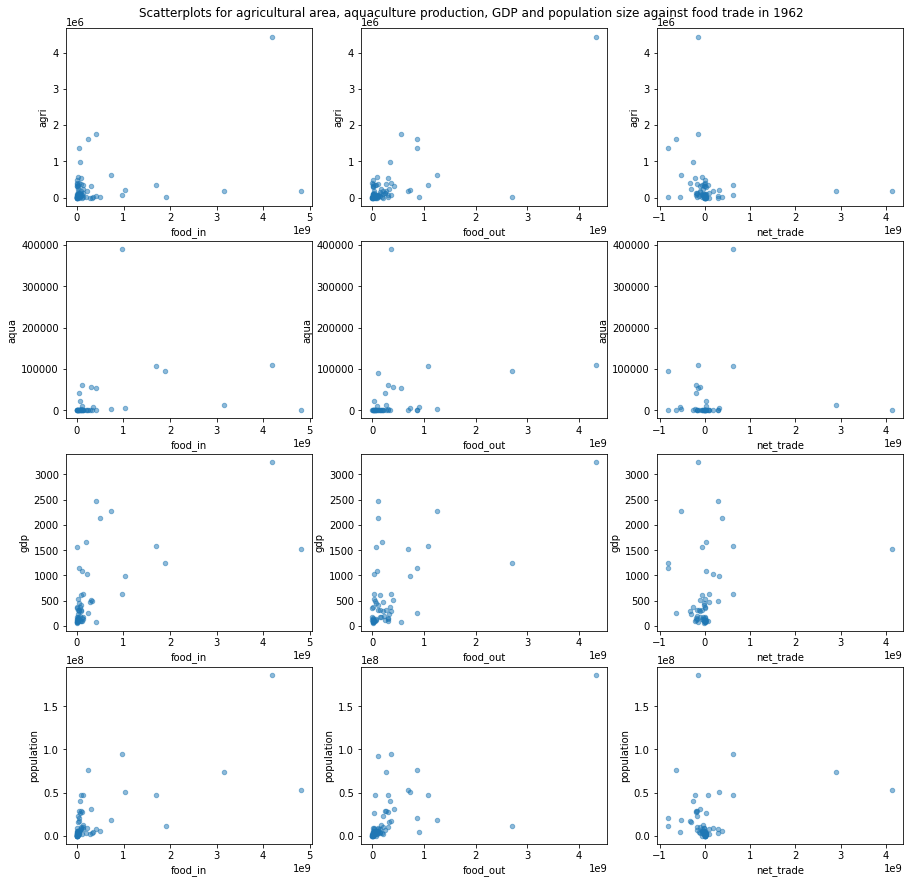

In [81]:
eda_q3b_subplots(1962)

The scatterplots appear to have quite similar distribution in both 1962 and 2018, which suggests the relationship between food production, GDP and population size against food trade has not changed much over the years.

These are unlikely to be linear relationships as all the plots seem to show many outliers with the rest of the values clustered in one area. There are likely other factors across the different countries that are related to food trade.

We also draw regression plots for the worldwide agricultural area, aquaculture production, GDP per capita and population size against food imports and food exports (over time, i.e. each point represents a different year), and calculate the Pearson correlation.

In [82]:
def eda_q3b_regplot_helper(ax, start_year, end_year, xlabel, ylabel):
    title = 'Worldwide ' + ylabel + ' vs ' + xlabel + ' from ' + str(start_year) + ' to ' + str(end_year)
    mask=(df_wb.country=='World')&(df_wb.year>=start_year)&(df_wb.year<=end_year)
    mask=mask&(df_wb[xlabel].notna())&(df_wb[ylabel].notna())
    print(title + ": " + str(stats.pearsonr(df_wb.loc[mask,xlabel],df_wb.loc[mask,ylabel])))
    sns.regplot(x=xlabel, y=ylabel, data=df_wb.loc[mask],ax=ax)
    ax.set_xlabel(label_dict[xlabel])
    ax.set_ylabel(label_dict[ylabel])
    ax.set_title(title)

Worldwide food_in vs agri from 1960 to 2020: (0.8010422319469133, 1.2346248587434928e-13)
Worldwide food_out vs agri from 1960 to 2020: (0.793676806852556, 8.188371908919902e-13)
Worldwide food_in vs aqua from 1960 to 2020: (0.9837374512188028, 1.0568924069315849e-39)
Worldwide food_out vs aqua from 1960 to 2020: (0.976759177210555, 1.942936877466229e-34)
Worldwide food_in vs gdp from 1960 to 2020: (0.9761951819374473, 3.415679223700045e-38)
Worldwide food_out vs gdp from 1960 to 2020: (0.9750098387752681, 2.641199292259567e-36)
Worldwide food_in vs population from 1960 to 2020: (0.91657550315587, 1.483251902543179e-23)
Worldwide food_out vs population from 1960 to 2020: (0.9158230682102557, 1.1870563844390844e-22)
Worldwide food_in vs agri from 1960 to 1991: (0.9449277732880621, 1.2818793055831227e-14)
Worldwide food_out vs agri from 1960 to 1991: (0.9290076958611381, 2.72210989122226e-12)


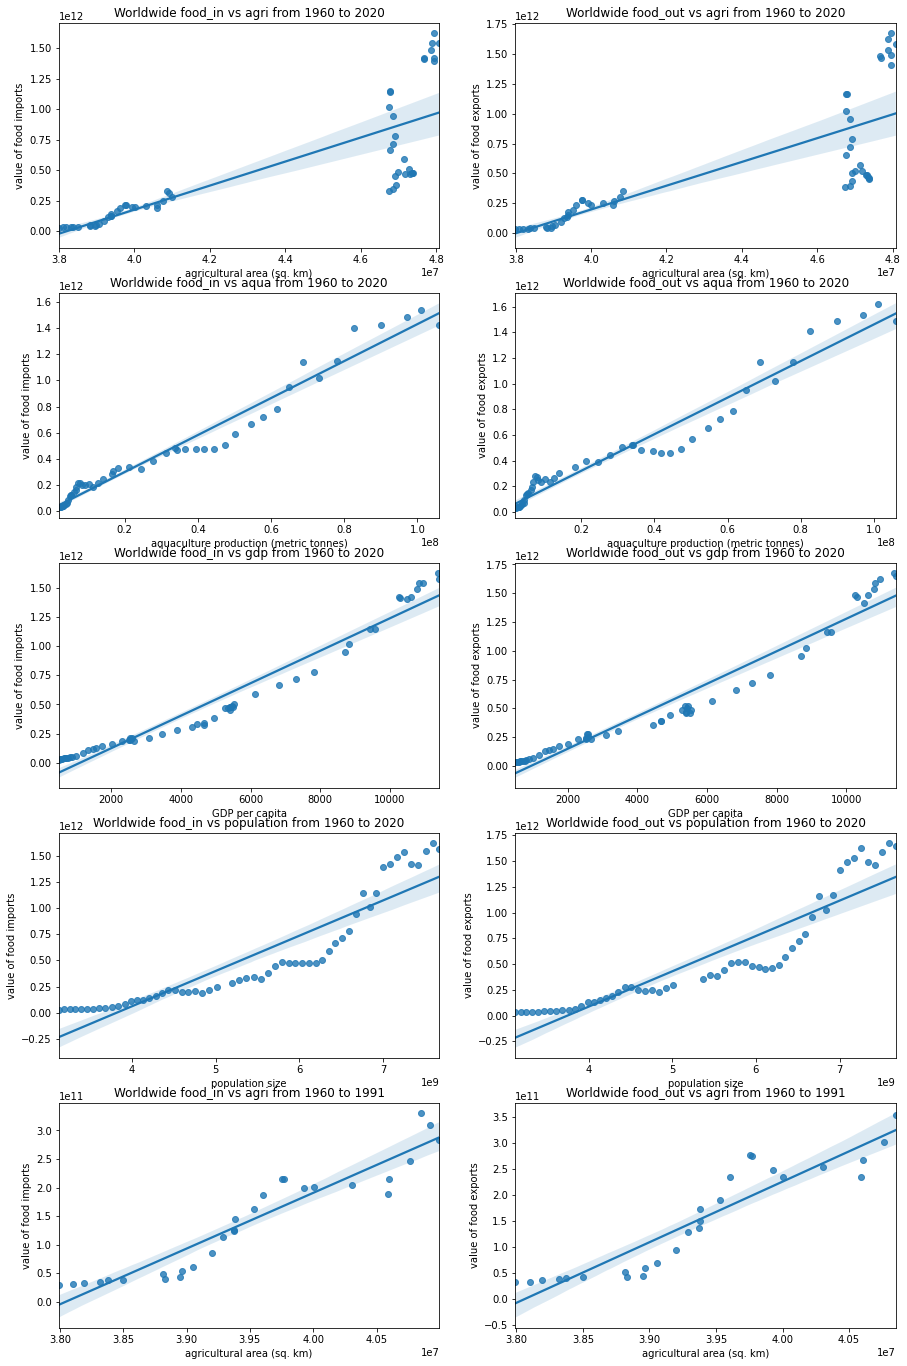

In [83]:
def eda_q3b_regplot():
    fig, axs = plt.subplots(5,2,figsize=(15,24))
    xlabel = ['agri','aqua','gdp','population']
    ylabel = ['food_in','food_out']
    for r in range(4):
        for c in range(2):
            eda_q3b_regplot_helper(axs[r,c], 1960, 2020, xlabel[r], ylabel[c])
    eda_q3b_regplot_helper(axs[4,0], 1960, 1991, xlabel[0], ylabel[0])
    eda_q3b_regplot_helper(axs[4,1], 1960, 1991, xlabel[0], ylabel[1])

eda_q3b_regplot()

As all of these have relatively high correlation coefficients (all above 0.9 except for agricultural area from 1960 to 2020) and p-values much less than 0.01, we will perform linear regression to predict the food imports and food exports (separately) on all of these variables, once using all the data from 1960 to 2020, again using only the data from 1960 to 1991, and using each of the 3 individual variables with correlation > 0.9 (from 1960 to 2020).

In [84]:
def eda_q3b_lrm(end_year, x, y):
    print('Linear Regression for ' + y + ' based on ' + str(x) + ' from 1960 to ' + str(end_year))
    cols = x.copy()
    cols.append(y)
    df = df_wb.loc[(df_wb.year<=end_year)&(df_wb.country=='World'), cols].copy()
    df.dropna(axis=0,how='any',inplace=True)
    data = df[x]
    lm = LinearRegression()
    x_train, x_test, y_train, y_test = train_test_split(data, df[y],
                                                        test_size=0.2, random_state=0)
    lm.fit(x_train, y_train)
    print('intercept: ' + str(lm.intercept_))
    print('coefficient(s): ' + str(lm.coef_))
    y_hat = lm.predict(x_test)
    mse = mean_squared_error(y_test, y_hat)
    print('MSE: ' + str(mse))
    print('R^2: ' + str(lm.score(x_train, y_train)))
    print()
    
    fig, axs = plt.subplots(1,2,figsize=(14,5))
    sns.kdeplot(y_test, color='r', label='Actual Value', ax=axs[0])
    sns.kdeplot(y_hat, color='b', label='Fitted Value', ax=axs[0])
    axs[0].set_title('Actual (red) and Fitted (blue) values of ' + label_dict[y])
    
    df_eval = pd.DataFrame({'Actual': y_test, 'Fitted': y_hat})
    df_eval.plot(kind='bar', ax=axs[1])
    axs[1].grid(which='major',color='grey',axis='both',alpha=0.5)
    axs[1].set_title('Bar graph of actual vs fitted values of ' + label_dict[y])

    if len(x)==1:
        fig, axs = plt.subplots(1,2,figsize=(14,5))
        plt.sca(axs[0])
        x_test = x_test.values.flatten()
        y_test = y_test.values.flatten()
        reg = sns.regplot(x=np.concatenate([x_test,x_test]), y=np.concatenate([y_hat,y_test]), color='b')
        sns.scatterplot(x=x_test, y=y_test, color='r', ci=100)
        plt.xlabel(label_dict[x[0]])
        plt.ylabel(label_dict[y])
        reg.grid(color='grey',axis='both',alpha=0.5)
        plt.legend(["Regression", "Train", "Regression Error", "Test"])
        plt.title(label_dict[y] + ' against ' + label_dict[x[0]])
        
        residuals = y_hat-y_test
        plt.sca(axs[1])
        plt.scatter(x=x_test, y=residuals)
        plt.plot([min(x_test), max(x_test)], [0,0], color="red", alpha=0.3)
        plt.title('Regression residuals against ' + label_dict[x[0]])
        plt.legend(['0','Residuals'], loc="upper left")
        plt.grid(color='grey',axis='both',alpha=0.5)
        plt.xlabel(label_dict[x[0]])
        plt.ylabel(label_dict[y])

We use the Mean-Squared-Error (MSE) and R-squared value to evaluate the relative effectiveness of the Simple Linear Regression and Multiple Linear Regression models.

A lower MSE indicates a better fit, while a higher R-squared value (closer to 1) indicates that a greater percentage of the variation of the dependent variable is explained by the linear model (i.e. a better fit).

Linear Regression for food_in based on ['agri', 'aqua', 'gdp', 'population'] from 1960 to 2020
intercept: 1087419292351.5691
coefficient(s): [-1.80352033e+04  7.53607215e+03  1.31249419e+08 -1.28188404e+02]
MSE: 1.7709961641467655e+21
R^2: 0.9941121294752091

Linear Regression for food_in based on ['agri', 'aqua', 'gdp', 'population'] from 1960 to 1991
intercept: 756782825991.6104
coefficient(s): [-2.47211695e+04 -9.13202252e+03  9.93660060e+07  5.68504372e+01]
MSE: 3.1601643263754404e+19
R^2: 0.996108559936307

Linear Regression for food_in based on ['agri'] from 1960 to 2020
intercept: -4033469949316.9526
coefficient(s): [105402.76055337]
MSE: 7.850288564703298e+22
R^2: 0.6645920513268825

Linear Regression for food_in based on ['agri'] from 1960 to 1991
intercept: -3946289214738.6914
coefficient(s): [103595.16458919]
MSE: 1.2157221167070495e+21
R^2: 0.905520292551741

Linear Regression for food_in based on ['aqua'] from 1960 to 2020
intercept: 21394323272.38965
coefficient(s): [1431

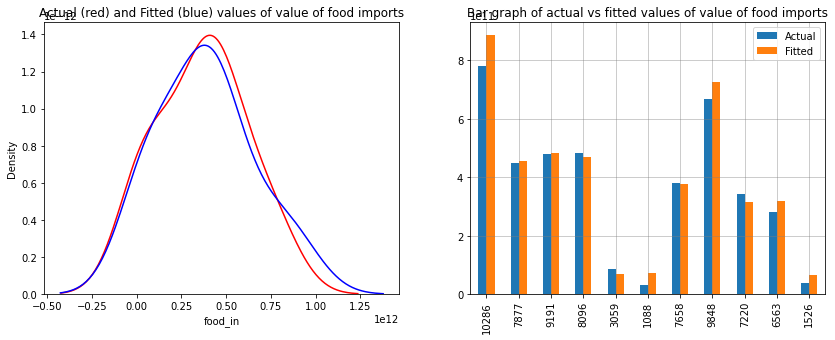

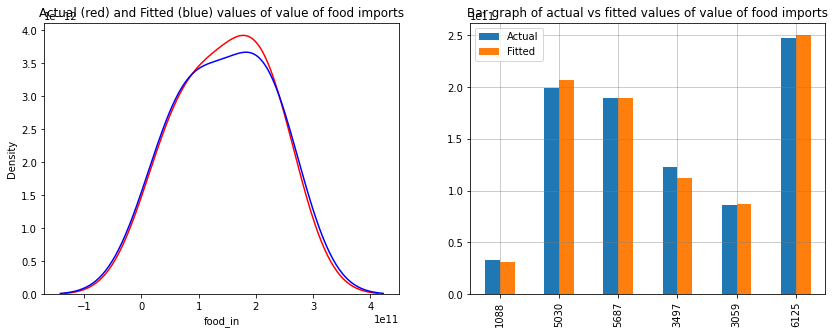

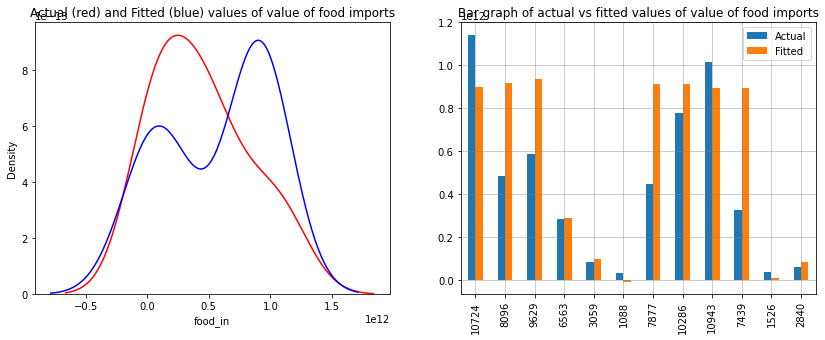

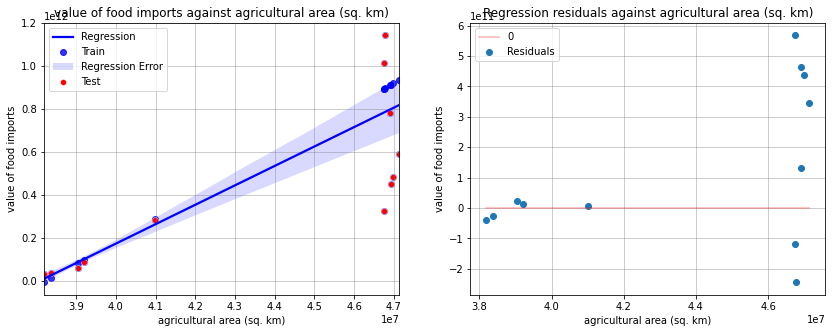

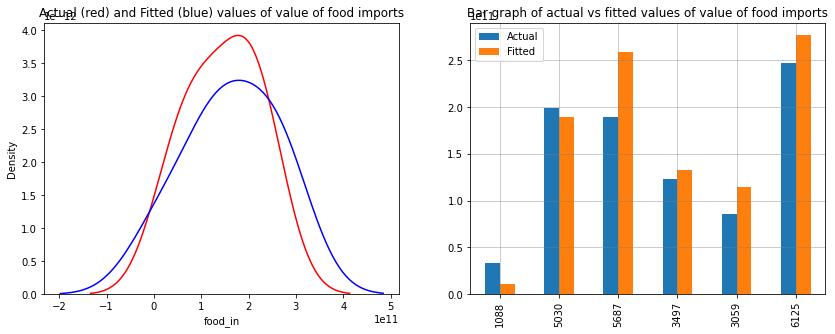

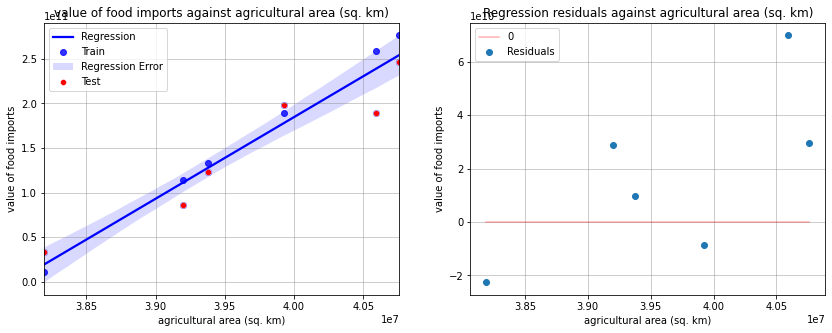

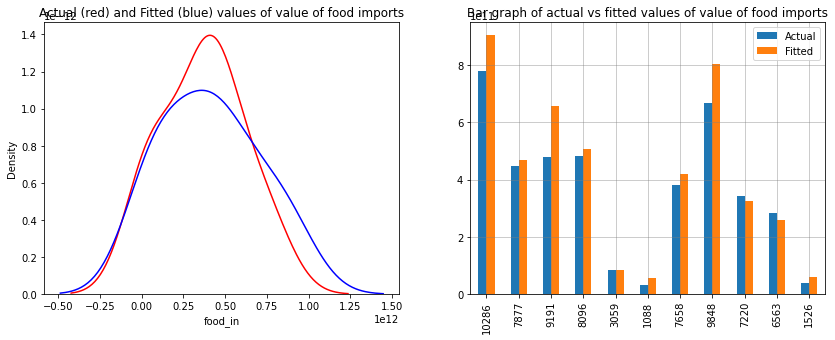

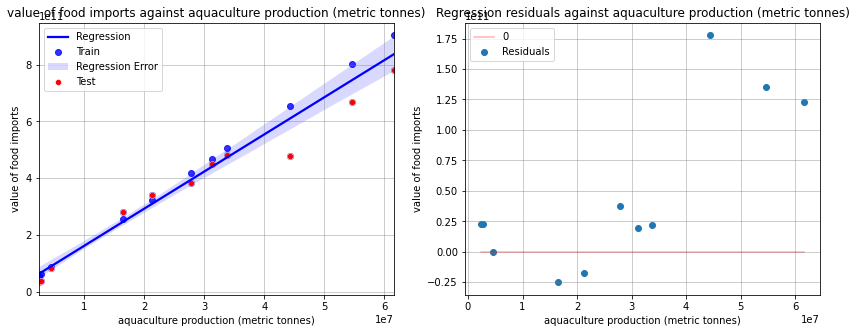

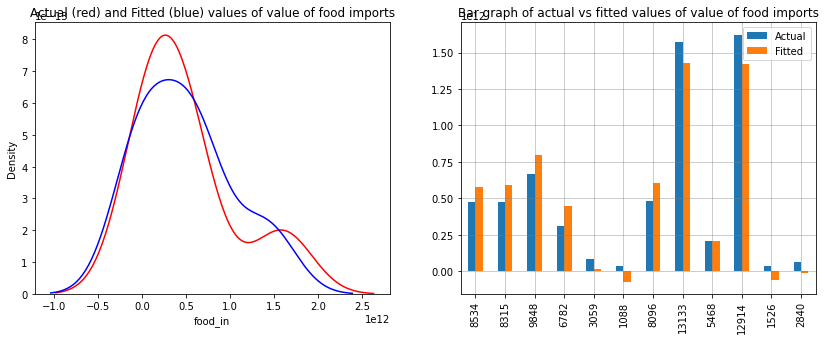

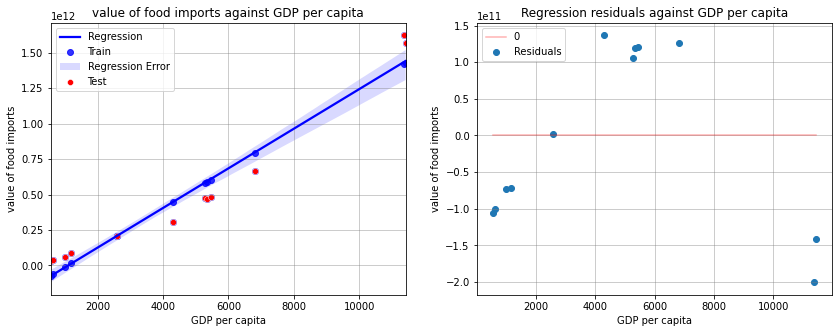

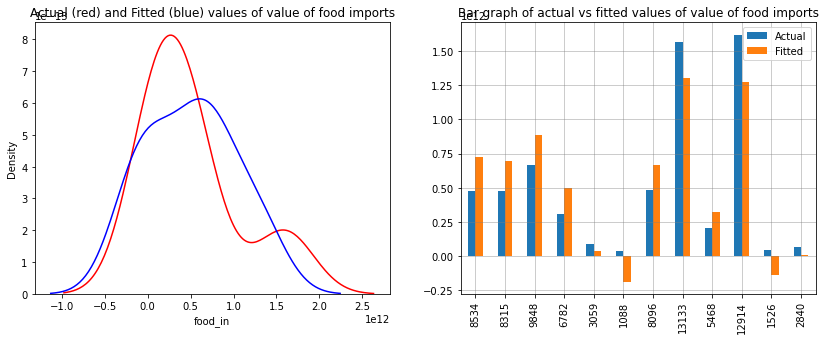

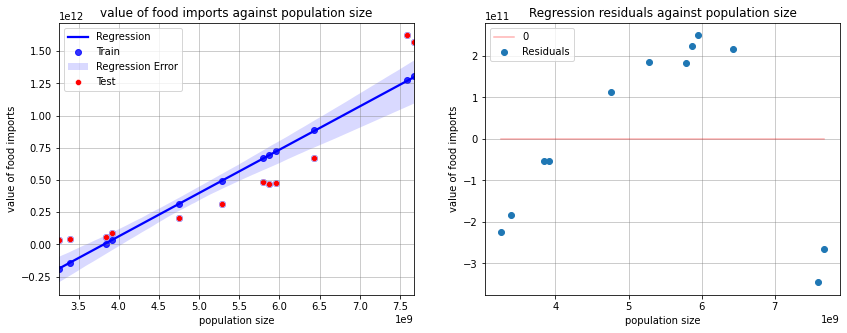

In [85]:
# food imports
eda_q3b_lrm(2020, ['agri','aqua','gdp','population'], 'food_in')
eda_q3b_lrm(1991, ['agri','aqua','gdp','population'], 'food_in')
eda_q3b_lrm(2020, ['agri'], 'food_in')
eda_q3b_lrm(1991, ['agri'], 'food_in')
eda_q3b_lrm(2020, ['aqua'], 'food_in')
eda_q3b_lrm(2020, ['gdp'], 'food_in')
eda_q3b_lrm(2020, ['population'], 'food_in')

###### Food imports
Using all 4 variables (agricultural area, aquaculture production, GDP and population size) provides the best fit compared to using only one of the variables. Using data from only 1960 to 1991 gives only a very slightly better fit compared to using all the data.

Among the individual variables, aquaculture production provides the best fit, followed by GDP, then agricultural area from 1960 to 1991, population size and lastly agricultural area from 1961 to 2020 (likely due to the inconsistency found earlier).

Notably, GDP seems to give a better fit than agricultural area. This could mean that any of these two possibilities (possibly some combination of both factors):
1. GDP is more closely correlated to food imports because a wealthier country can afford to import more food, which is more relevant to food imports than the amount of food production, or
2. Agricultural area is not representative enough of overall agriculture production, hence making it seem less related to the food imports than it really is; in this case, food imports may or may not be more closely related to food production as it is to GDP.

Linear Regression for food_out based on ['agri', 'aqua', 'gdp', 'population'] from 1960 to 2020
intercept: 1580579068783.063
coefficient(s): [-3.12907057e+04  4.92877755e+03  1.70191388e+08 -1.26718263e+02]
MSE: 3.940382221444456e+21
R^2: 0.9888898476135984

Linear Regression for food_out based on ['agri', 'aqua', 'gdp', 'population'] from 1960 to 1991
intercept: -790701716608.1685
coefficient(s): [ 1.99848960e+04 -2.15917388e+04  1.57820773e+08  6.03351398e+00]
MSE: 5.3846457332046406e+19
R^2: 0.992230806285066

Linear Regression for food_out based on ['agri'] from 1960 to 2020
intercept: -3659407840272.63
coefficient(s): [96404.22452491]
MSE: 1.267200279389095e+23
R^2: 0.6318233602851724

Linear Regression for food_out based on ['agri'] from 1960 to 1991
intercept: -4524149311928.109
coefficient(s): [118771.09759995]
MSE: 9.860367359471429e+20
R^2: 0.859414074574081

Linear Regression for food_out based on ['aqua'] from 1960 to 2020
intercept: 35809976875.85394
coefficient(s): [14251

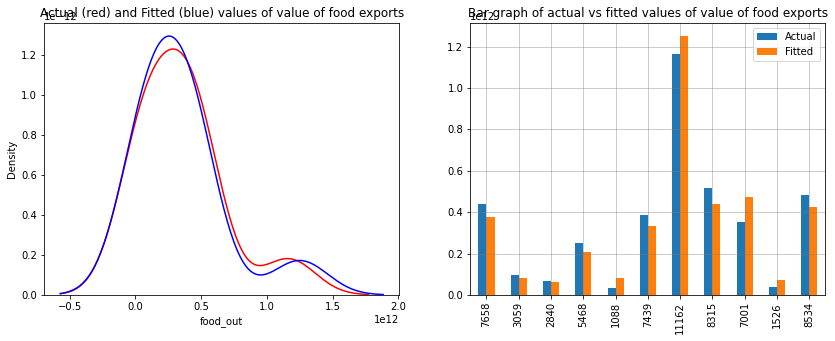

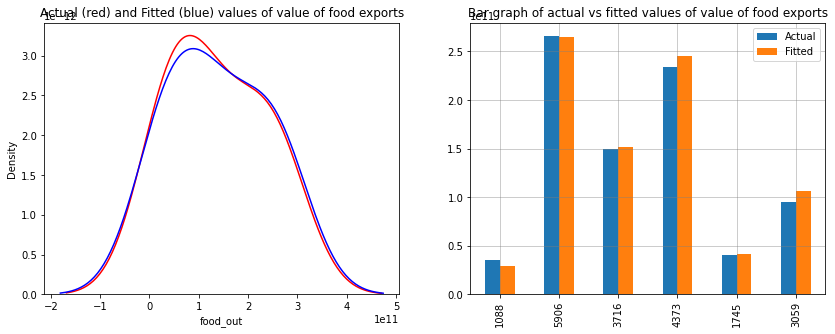

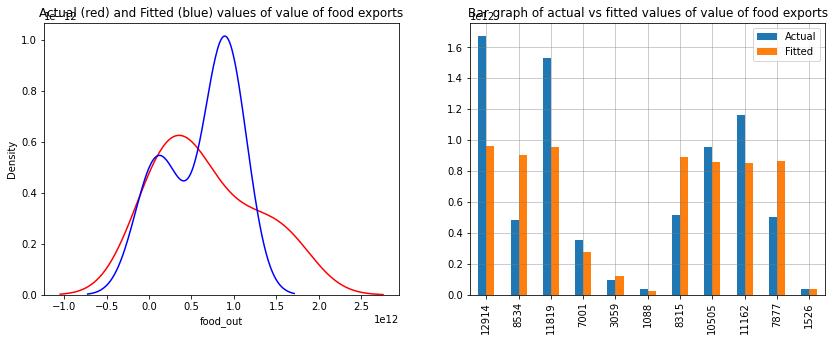

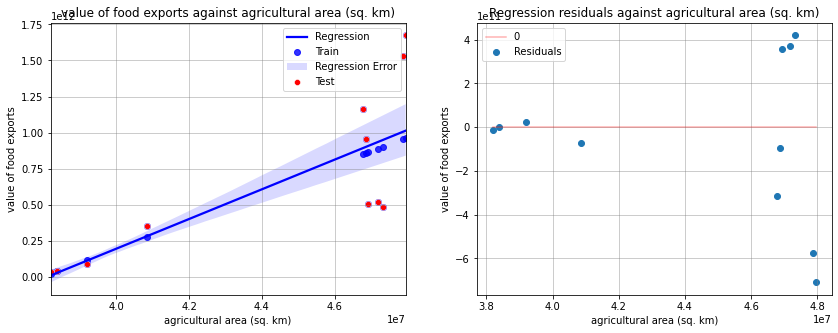

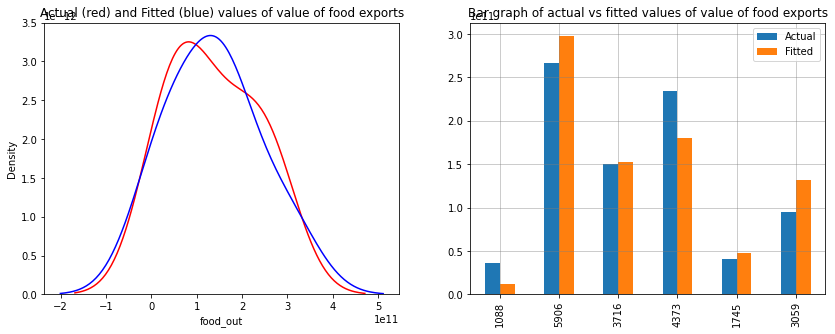

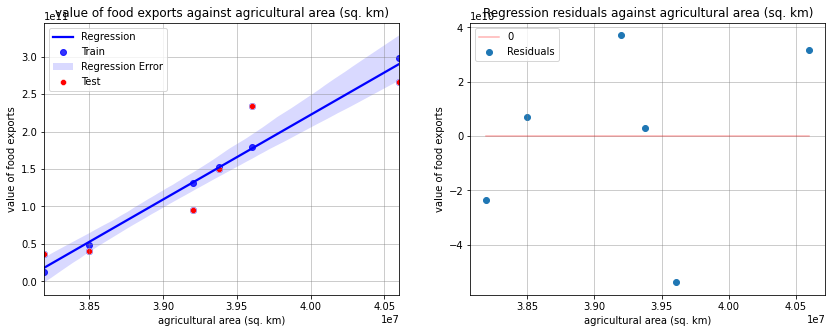

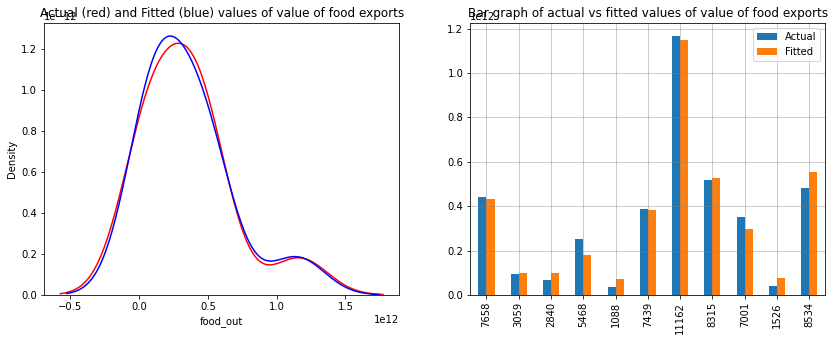

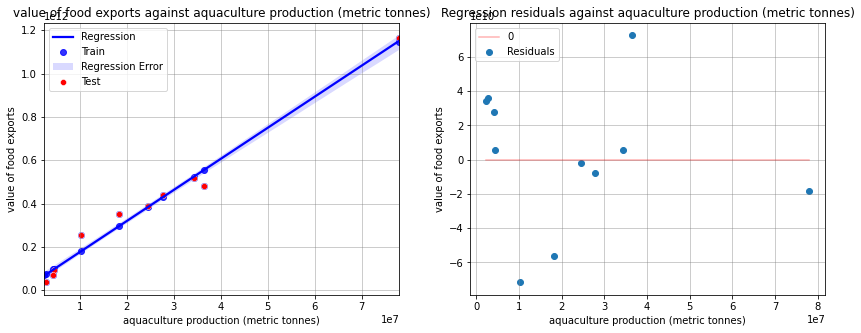

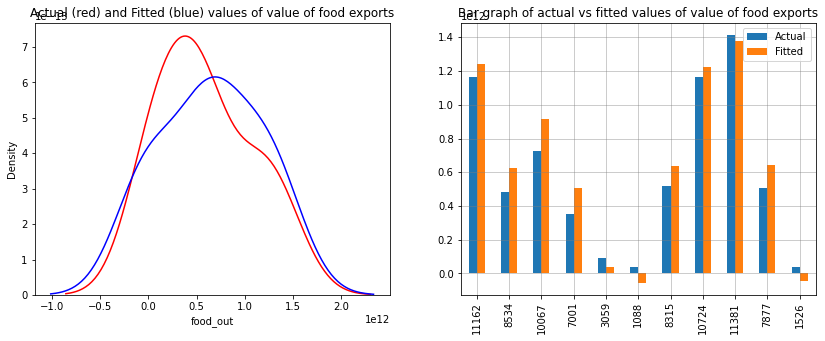

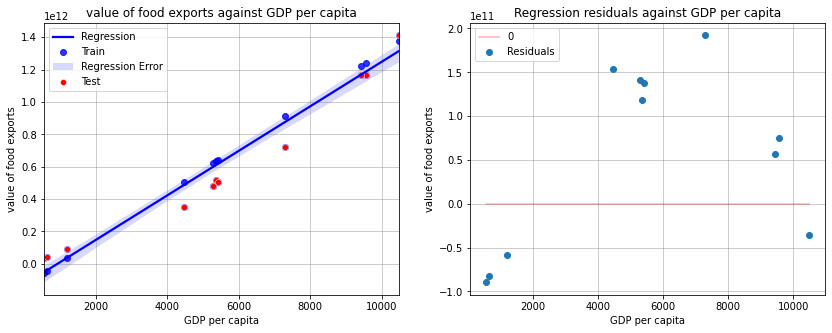

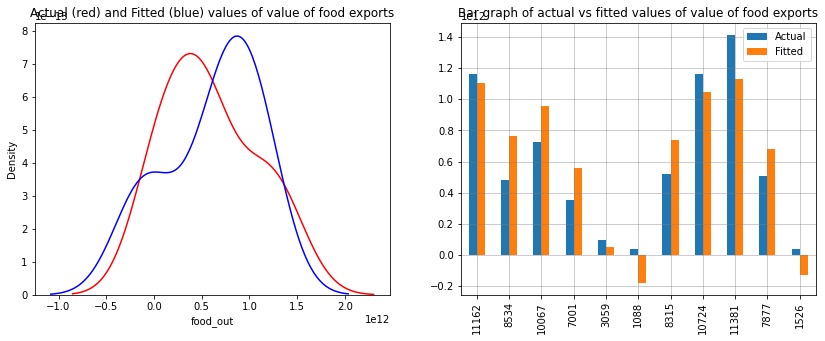

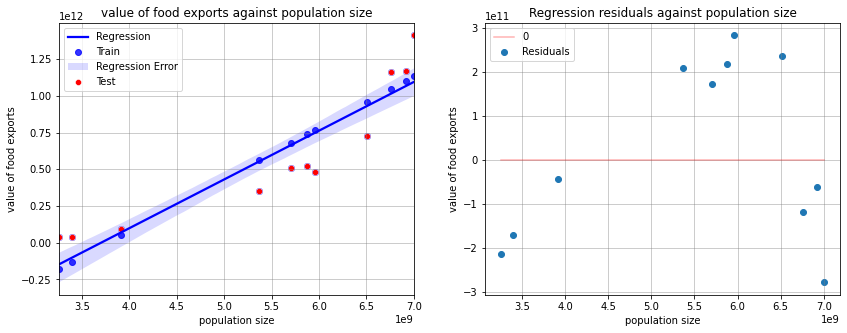

In [86]:
# food exports
eda_q3b_lrm(2020, ['agri','aqua','gdp','population'], 'food_out')
eda_q3b_lrm(1991, ['agri','aqua','gdp','population'], 'food_out')
eda_q3b_lrm(2020, ['agri'], 'food_out')
eda_q3b_lrm(1991, ['agri'], 'food_out')
eda_q3b_lrm(2020, ['aqua'], 'food_out')
eda_q3b_lrm(2020, ['gdp'], 'food_out')
eda_q3b_lrm(2020, ['population'], 'food_out')

###### Food exports
Using all 4 variables (agricultural area, aquaculture production, GDP and population size) provides the best fit compared to using only one of the variables. Using data from only 1960 to 1991 gives only a very slightly better fit compared to using all the data.

Among the individual variables, GDP provides the best fit, followed by aquaculture production, then agricultural area from 1960 to 1991, population size and lastly agricultural area from 1961 to 2020 (likely due to the inconsistency found earlier).

Notably, GDP gives the best fit this time. (Though there is not a lot of difference between GDP and aquaculture.) This could be because food exports help to contribute significantly to profits of various countries.

Agricultural area provides a significantly worse fit than aquaculture production in this section. This could, again, be due to the discrepancy between agricultural area and agriculture production. Alternatively, there is a chance that this may also suggest that countries export aquaculture products more than agriculture products, perhaps because agriculture products can be grown in artificially maintained environments and need not necessarily be imported/exported.

#### Food Waste
##### Q4<a id='ex4'/>
We would like to investigate possible factors related to food waste.

First, we plot heatmaps of the count of available data.

In [87]:
def eda_q4_heatmap(col):
    heatmap_df = df_waste.groupby(['country',col])[['loss']].count()
    heatmap_df = pd.pivot_table(heatmap_df, values='loss', index='country', columns=col)
    plt.figure(figsize=(15,15))
    plt.title('Heatmap of available data (number of observations by country and ' + col)
    sns.heatmap(heatmap_df, cmap="YlGnBu") # yellow is few data points, blue is many data points
    plt.show()

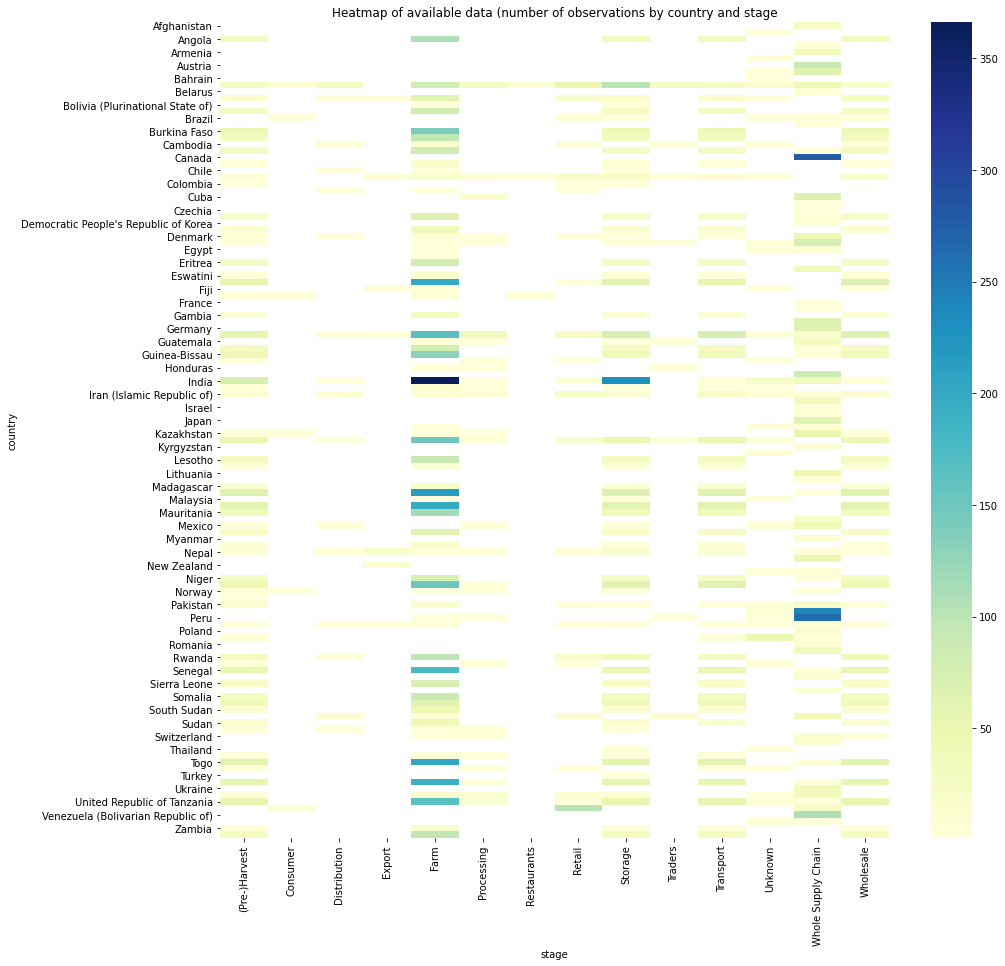

In [88]:
eda_q4_heatmap('stage')

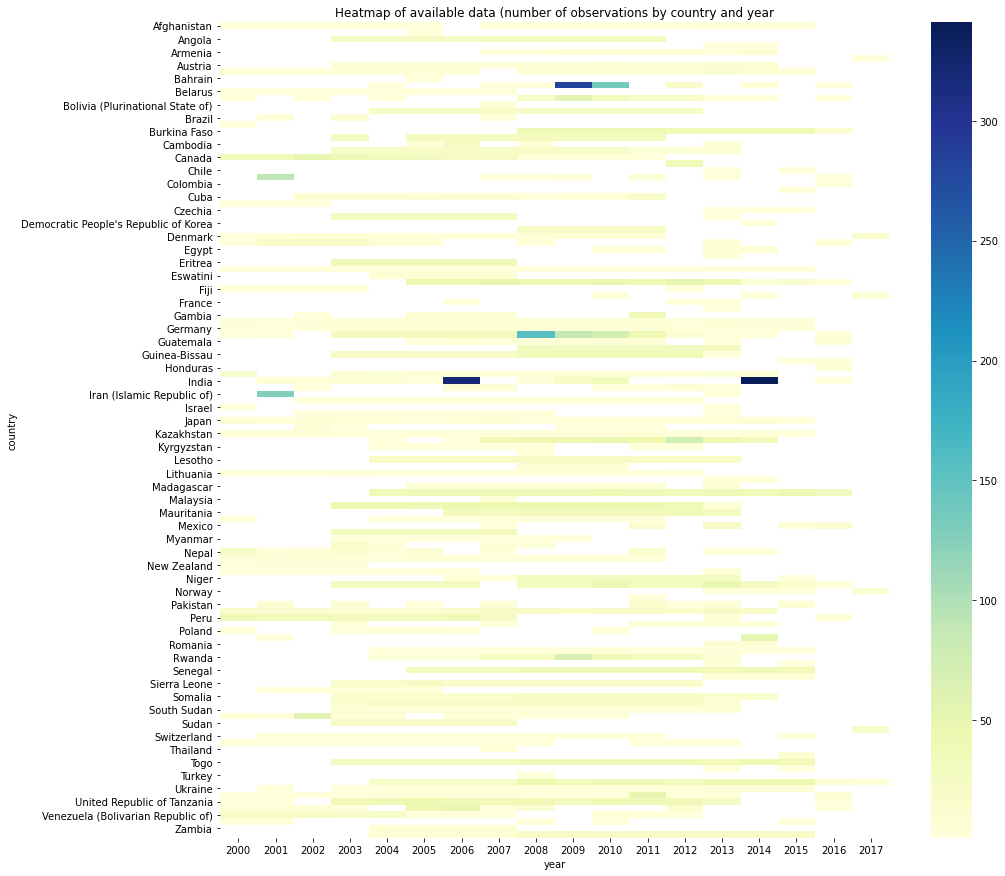

In [89]:
eda_q4_heatmap('year')

In [ ]:
eda_q4_heatmap('crop_group')

We notice that the data is very sparse.

How does the amount of food waste generated change:

###### A. Over the years?
We draw boxplots and violinplots for the percentage of food lost (for each observation represented by each row of data) over the years for all the observations (disregarding the stage of the food production chain). This allows us to compare the overall worldwide change in food waste.

In [ ]:
def eda_q4a_boxplot(x,y):
    plt.figure(figsize=(15,8))
    plt.ylabel('percentage of food lost')
    plt.title('Boxplots of percentage of food lost from 2000-2017')
    sns.boxplot(y=y,x=x)
    plt.show()

eda_q4a_boxplot(df_waste['year'],df_waste['loss'])

Median amount of food waste detected in any stage of the food supply chain and in any country reached its highest at ~10% in 2002, while Q3 has reached its highest at ~20% in 2002 and the maximum reached its highest at ~80% in 2017 (which is quite alarming). The amount of food waste appears to have been increasing significantly in recent years (comparing medians from 2014 to 2017).

We suspect the huge differences between certain years (e.g. 2002-2003, 2016-2017) could be because of differing availability of data rather than actual significant increases/decreases, as the data is quite inconsistent and from many different sources (and with many boxplot outliers), and there were no particularly important events that could have triggered such a sudden increase/decrease.

Since the FAO food waste dataset does not include data from Singapore, we shall also do some analysis on the food waste in Singapore by drawing a stacked area chart.

In [ ]:
df_waste_sg.plot(kind='area',x='year',y=['recycled','disposed'], figsize=(12,8), alpha=0.5, stacked=True)
plt.ylabel('Food Waste (tonnes)')
plt.xlabel('Year')
plt.xticks(np.arange(2011,2021))
plt.title('Food Waste in Singapore from 2011 to 2020')

Total amount of food waste generated in Singapore hit its peak in 2017 and has been decreasing ever since. We attribute part of the decrease from 2017 onwards (especially 2019 onwards) to consistent campaign efforts, both by the government and by activist groups, regarding environmental sustainability including food waste.

The amount of food waste recycled has been increasing slightly over the years, but is still relatively low (significantly less than half). There was also a slight decrease from 2019 to 2020. The overall increase could possibly be due to more awareness as well as improvements in technology.

###### B. Across countries?
We draw choropleth maps of the median and mean percentage of food lost in each country (regardless of crops)

In [ ]:
draw_map(df_waste.groupby(['country'])[['loss']].median().reset_index(),
                 'loss','Median percentage of food lost from 2000 to 2017')

In [ ]:
draw_map(df_waste.groupby(['country'])[['loss']].mean().reset_index(),
                 'loss','Mean percentage of food lost from 2000 to 2017')

In [ ]:
def eda_q4b_map(year):
    return draw_map(df_waste[df_waste.year==year].groupby(['country'])[['loss']].median().reset_index(),
                    'loss', 'Median percentage of food lost in ' + str(year))

interact(eda_q4b_map,
         year=[i for i in range(2000,2018)])

At first glance for the median and mean percentages over the years, it seems that Australia has the most food waste. However, by inspecting the specific years' maps, we realise this was mainly contributed by a lot of food waste recorded for Australia in 2017.

It is rather difficult to make comparisons involving all the maps/years as the places where data is available keep changing. We attempt to remove Australia and plot the medians again, to see if it helps to make the data points appear more distinct.

In [ ]:
df = df_waste.groupby(['country'])[['loss']].median().reset_index()
draw_map(df[df['country']!='Australia'],
                 'loss','Median percentage of food lost from 2000 to 2017')

Peru, Algeria, Gabon and Oman appear to have the highest recorded median percentage of food waste.


###### C. In relation to food production, food trade, GDP per capita and population size?
We draw scatter plots of percentage of food lost (for different countries and different crops in different years) against
- agricultural area, percentage area for agriculture and aquaculture production
- food imports, food exports and net food trade
- GDP per capita
- population size

In [ ]:
def eda_q4c_scatter():
    y_df = df_waste.groupby(['country','year'])[['loss']].median().reset_index()
    x = ['agri','agri_pc','aqua','food_in','food_out','gdp','population']

    fig, axs = plt.subplots(7, 1, figsize=(12,54))

    for i in range(7):
        df = pd.merge(left=df_wb.loc[:,['country','year',x[i]]],
                      right=y_df,
                      on=['country','year'])
        df.dropna(axis=0,how='any',inplace=True)
        title = 'Percentage of food lost against ' + label_dict[x[i]]
        print(title + ': ' + str(stats.pearsonr(df[x[i]],df['loss'])))
        sns.scatterplot(x=df[x[i]],y=df['loss'],data=df,alpha=0.2,ax=axs[i])
        axs[i].set_xlabel(label_dict[x[i]])
        axs[i].set_ylabel('Percentage of food lost')
        axs[i].set_title(title)
    plt.show()

In [ ]:
eda_q4c_scatter()

According to the scatterplots above, there is no linear correlation between any of the variables and the median food waste.

We notice that there are two clusters for population size (likely due to India and China having population sizes much larger than the rest of the world).

###### D. Across different crops / crop groups?
We draw a categorical boxplot and stripplot of percentage of food lost against the crop groups.

In [ ]:
def eda_q4de_boxplot(figsize, y):
    plt.figure(figsize=figsize)
    plt.xlabel('percentage of food lost')
    plt.title('Boxplots of percentage of food lost across ' + y)
    df = df_waste[df_waste[y]!='Unknown']
    sns.stripplot(x='loss',y=y,data=df,jitter=0.2,alpha=0.2,color='black')
    sns.boxplot(x='loss',y=y,data=df)
    plt.show()

In [ ]:
eda_q4de_boxplot((10,22), 'crop_group')

The median percentage is highest for vegetables, followed by fruits and nuts, then edible roots and tubers. Perhaps this could be because people tend to be very particular about the "quality" (or rather, how good or "perfect" the food looks) when it comes to these types of foods (e.g. vegetable leaves with holes are considered imperfect by consumers), which also may make producers inclined to dispose of "imperfect" products. Alternatively, these products could have a shorter shelf life than some of the other products, contributing to a higher probability of them being wasted.

###### E. In different stages of the food production/consumption process?
We draw a categorical boxplot and stripplot for the percentage of food lost in the different stages over the years.

In [ ]:
eda_q4de_boxplot((15,28), 'stage')

Comparing medians, consumers appear to contribute the most food waste, followed by retail, then exports. The maximum percentage loss comes from transport, followed by processing, then the whole supply chain, then harvest/pre-harvest. Also, there is a lot of data available for storage, transport, harvest/pre-harvest, wholesale, farms and the supply chain as a whole.

Clearly, consumers should do our part to reduce food waste, as we are prone to wasting large amounts of our food. However, concurrently, it is also important that producers try to minimise the amount of food wasted before food even reaches the consumer, by optimising their processes and ensuring the food is handled properly and in ideal conditions.

Next, we draw word clouds based on the frequency of words in the activity descriptions and causes listed in the data, because the data for these columns are less structured and harder to categorise.

In [ ]:
df_waste.activity.value_counts(), df_waste.cause.value_counts()

In [ ]:
def white_bg_color_func(word, font_size, position, orientation, random_state=None,
                    **kwargs): # some colours in the default colour scheme are hard to see on white
    return "hsl({}, {}%, {}%)".format(np.random.randint(120,270),
                                      np.random.randint(70,90),
                                      np.random.randint(20,60)) 

def eda_q4e_wordcloud(col):
    col = col.copy()
    col = col.sample(frac=1) # randomly shuffle because only the first 2000 words will be taken
    wc_text = ''
    for c in col.values:
        if c != 'Unknown':
            wc_text = wc_text + c.lower() + ' '
    wc = WordCloud(
        background_color='white',
        max_words=2000,
        color_func=white_bg_color_func,
        collocations=False
    )
    wc.generate(wc_text)
    plt.figure(figsize=(15,10))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [ ]:
eda_q4e_wordcloud(df_waste.activity)

In [ ]:
eda_q4e_wordcloud(df_waste.cause)

From the `WordCloud`s, we see that storange, transport, retail and threshing (process of loosening the edible part of grain (or other crop) from the straw to which it is attached) are common activities during which food is wasted. Causes may include things like improper handling of the food, perhaps such as storing them under undesirable conditions that make it spoil faster, or being too rough with the food.

## Results & Visualisation<a id='results'/>


### Food Production
#### Q1
Agricultural land area and aquaculture production have been increasing over the years, and there has been a notable increase in rate of change for aquaculture production.

There is a sudden spike in agricultural land area from 1991 to 1992 in the dataset due to the addition of data for countries that had not previously been in the dataset.

In [ ]:
interact(eda_q1a_pointplot,
         y=widgets.Dropdown(options=list(df_wb.select_dtypes('float64').columns[2:5]),description='y-axis'),
         country=widgets.Dropdown(options=countries,value='World'),
         start_year=widgets.IntSlider(min=1960,max=2020,step=1,value=1960,description='start year'),
         end_year=widgets.IntSlider(min=1960,max=2020,step=1,value=2020,description='end year'))

Alaska, the United States of America, China and Australia have the greatest mean agricultural area, as well as aquaculture production, from 1961 to 2018. Notably, China has aquaculture production very much higher than all the other countries, and countries with the highest percentage of land area used for agriculture are mainly situated in Europe, Asia or Africa.

In [ ]:
interact(eda_q1b_map,
         y=widgets.Dropdown(options=list(df_wb.select_dtypes('float64').columns[2:5]),description='y-axis'),
         start_year=widgets.IntSlider(min=1960,max=2020,step=1,value=1960,description='start year'),
         end_year=widgets.IntSlider(min=1960,max=2020,step=1,value=2020,description='end year'))

Worldwide food production is positively correlated with GDP per capita as well as population size.

In [ ]:
eda_q1c_regplot()

In [ ]:
eda_q1d_regplot()

#### Q2
Worldwide, a larger agricultural area is generally correlated with more aquaculture production, and overall aquaculture production appears to increase at a slightly faster rate than agricultural area.

In [ ]:
eda_q2_scatter()

However, there are some exceptions, as the geography of countries vary. For example, Kazakhstan has a relatively low aquaculture production but very high agricultural area, which is likely because it is the world's largest land-locked country (it shares a small boundary with a water body that is surrounded by land).

Further analysis suggests that faster development of aquaculture production and slower increase / decline in agricultural area might be correlated with being more developed. For example, China had an increase in agricultural area which gradually reached a plateau, while its aquaculture production started to boom only after several years.

### Food Trade
#### Q3
Value of both imports and exports have been increasing over the years. Total value of exports is typically higher than that of imports.

In [ ]:
print('You can select multiple countries.')
interact(eda_q3a_pointplot,
         y=widgets.Dropdown(options=list(df_wb.select_dtypes('float64').columns[5:8]),description='y-axis'),
         country=widgets.SelectMultiple(options=countries,value=['World']))

Using linear regression with mean-squared-error and R-squared value to compare different models, we arrive at the following results:

For both imports and exports, regression with all 4 variables (agriculture, aquaculture, GDP and population) is produces least error.

Food imports are most closely related to aquaculture production, followed by GDP. We suggest a few possible explanations:

1. GDP is more closely correlated to food imports because a wealthier country can afford to import more food, which is more relevant to food imports than the amount of food production, or
2. Agricultural area is not representative enough of overall agriculture production, hence making it seem less related to the food imports than it really is; in this case, food imports may or may not be more closely related to food production as it is to GDP.

Food exports are most closely related to GDP, followed by aquaculture production. The difference is not very significant, but this could be because food exports help to contribute significantly to profits of various countries, allowing GDP to increase. Also, agricultural area provides a significantly worse fit than aquaculture production in this section. This could be due to the discrepancy between agricultural area and agriculture production, or it could suggest countries export aquaculture products more than agriculture products, perhaps because agriculture products can be grown in artificially maintained environments and need not necessarily be imported/exported, unlike certain species of seafood that are native to certain places.

In [ ]:
eda_q3b_lrm(2020, ['agri','aqua','gdp','population'], 'food_in')
eda_q3b_lrm(1991, ['agri'], 'food_in')
eda_q3b_lrm(2020, ['aqua'], 'food_in')
eda_q3b_lrm(2020, ['gdp'], 'food_in')

In [ ]:
eda_q3b_lrm(2020, ['agri','aqua','gdp','population'], 'food_out')
eda_q3b_lrm(1991, ['agri'], 'food_out')
eda_q3b_lrm(2020, ['aqua'], 'food_out')
eda_q3b_lrm(2020, ['gdp'], 'food_out')

### Food Waste
#### Q4
Rather unexpectedly, there is almost no correlation between food waste and any of the above factors (food production/trade, GDP, population). Perhaps poor consumer habits or bad practices in food production do not change significantly across countries; the food waste dataset is too incomplete for any definitive conclusions to be made.

In [ ]:
eda_q4c_scatter()

There are overall increasing trends in food waste in recent years up to 2017.

In [ ]:
eda_q4a_boxplot(df_waste['year'],df_waste['loss'])

There are no particular trends related to location of countries with the most/least food waste on the world map.


In [ ]:
df = df_waste.groupby(['country'])[['loss']].median().reset_index()
draw_map(df[df['country']!='Australia'],
                 'loss','Median percentage of food lost from 2000 to 2017')

The median percentage of food lost is highest for vegetables, followed by fruits and nuts, then edible roots and tubers.


In [ ]:
eda_q4de_boxplot((10,22), 'crop_group')

Consumers appear to contribute the most food waste, followed by retail, then exports.

In [ ]:
eda_q4de_boxplot((15,28), 'stage')

## Conclusion & Recommendations<a id='conclusion'/>

In conclusion, we have explored and discussed the relationships between food production, food trade and food waste as well as possible reasons behind the trends for each. While some strong correlations have been found, mainly when comparing data over time, there may also be other factors affecting some of these trends, such as differences in demand across countries.

### Limitations
As mentioned in earlier parts of the report (particularly elaborated in [Q2](#ex2), the fact that agricultural land may not be a precise indicator of agriculture production is a limitation of this project.

In addition, the World Bank website states that complete consistency across countries and over time for the agricultural land dataset is not possible; for example, data on agricultural land in different climates might not be comparable. Throughout this project, we make the assumption that the data is comparable and sufficiently accurate.

It is also unfortunate that the FAO dataset did not have any data on food waste in Singapore, and the data was quite inconsistent and from many different sources, making it difficult to compare trends over time across different places.

### Recommendations
It would be good if governments could start keeping track of their food waste in a more organised and consistent manner along with which part of the food supply chain the food was lost, which would allow more investigation to accurately discover the causes of food waste and what can be done to reduce it.

Consumers need to be more mindful of our own food waste as well, by reminding ourselves and the people around us to not buy more than we need and try to finish our food or store it properly.

## References<a id='refs'/>
### Datasets
For the exact URLs to each dataset, please refer to the [Datasets](#datasets) section above.
- [World Bank Open Data](https://data.worldbank.org/)
- [Data.gov.sg](https://data.gov.sg/)
- [Food and Agriculture Organisation of the United Nations](https://www.fao.org/)
- [National Environment Agency](https://www.nea.gov.sg/)
- [United Nations Statistics Division](https://unstats.un.org/)
### Others
- [Singapore Food Agency](https://www.sfa.gov.sg/)
- [Wikipedia](https://en.wikipedia.org/)

## Appendix<a id='appendix'/>

Q1A/Q3A: An initial plan was to draw boxplots/violinplots to compare the overall worldwide change in food production over time.

However, this was only relevant for the percentage of agricultural area.

As shown below, the other values varied a lot across countries and there were many outliers, so the plots were difficult to analyse.

In [ ]:
eda_year_boxplots(df_wb[['country','year','agri']])

In [ ]:
eda_year_boxplots(df_wb[['country','year','aqua']])

In [ ]:
eda_year_boxplots(df_wb[['country','year','food_in']])

In [ ]:
eda_year_boxplots(df_wb[['country','year','food_out']])

In [ ]:
eda_year_boxplots(df_wb[['country','year','net_trade']])

Q4C: tried to plot with crop group as hue, but it was quite difficult to see any patterns in the colours

In [ ]:
y_df = df_waste.groupby(['country','year','crop_group'])[['loss']].median().reset_index()
x = ['agri','agri_pc','aqua','food_in','food_out','gdp','population']

fig, axs = plt.subplots(7, 1, figsize=(12,54))

for i in range(7):
    df = pd.merge(left=df_wb.loc[:,['country','year',x[i]]],
                  right=y_df,
                  on=['country','year'])
    df.dropna(axis=0,how='any',inplace=True)
    title = 'Percentage of food lost against ' + label_dict[x[i]]
    print(title + ': ' + str(stats.pearsonr(df[x[i]],df['loss'])))
    sns.scatterplot(x=df[x[i]],y=df['loss'],data=df,alpha=0.2,ax=axs[i],hue='crop_group')
    axs[i].set_xlabel(label_dict[x[i]])
    axs[i].set_ylabel('Percentage of food lost')
    axs[i].set_title(title)
plt.show()